# F1 Race Performance Analysis

This notebook explores Formula 1 telemetry and timing data using the **FastF1** API.

**Focus areas:**
- Pre-race practice analysis (FP1 / FP2)
- Lap time and driver performance comparison
- Tyre compound analysis: short-run (quali pace) and long-run (race pace)
- Fuel correction and tyre degradation modelling
- Stint length simulation

**Tools & Libraries:** FastF1, Pandas, NumPy, Matplotlib, Seaborn, SciPy

**Data Source:** FastF1 API (official F1 timing and telemetry data)

> Sessions and drivers used throughout this notebook are examples and can be changed to any race/driver of your choice.

In [1]:
import fastf1
import fastf1.legacy
from fastf1 import plotting
from fastf1.core import Laps
from fastf1.ergast import Ergast

from timple.timedelta import strftimedelta
from datetime import timedelta

import pandas as pd
import numpy as np
import seaborn as sns
import os

import plotly.express as px
from plotly.io import show

from scipy.stats import linregress

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import colormaps
from matplotlib.collections import LineCollection

# Cache

In [2]:
fastf1.Cache.enable_cache('cache') 
# For quick-access memory  

In [3]:
fastf1.set_log_level('WARNING')
# The available levels are (in order of increasing severity): 
# DEBUG, INFO, WARNING, ERROR and CRITICAL.

In [4]:
fastf1.Cache.get_cache_info

<bound method Cache.get_cache_info of FastF1 cache (524.84 MB) cache>

## Pre-Race Analysis

### Car & Driver Performance

#### Fastest Lap Time Among All Drivers

In [5]:
session = fastf1.get_session(2025, 'Jeddah', 'FP1')
session.load()

In [6]:
# Data containers
lap_times = []
driver_names = []
colors = []

# Collect fastest valid lap from each driver
for driver in session.drivers:
    driver_laps = session.laps.pick_drivers(driver)
    valid_laps = driver_laps.pick_accurate()

    if not valid_laps.empty:
        fastest_lap = valid_laps.pick_fastest()
        lap_times.append(fastest_lap['LapTime'].total_seconds())
        driver_names.append(fastest_lap['Driver'])
        driver_color = fastf1.plotting.get_driver_color(fastest_lap['Driver'], session) # fastf1.plotting.get_team_color(fastest_lap['Team'], session)
        colors.append(driver_color)

# Zip and sort
combined = sorted(zip(lap_times, driver_names, colors))
lap_times, driver_names, colors = zip(*combined)

# Calculate gaps to fastest lap
fastest_lap_time = min(lap_times)
lap_gaps = [t - fastest_lap_time for t in lap_times]

# Format top 3 driver info for legend
legend_labels = []
legend_handles = []
for i in range(min(3, len(driver_names))):
    td = timedelta(seconds=lap_times[i])
    m, s = divmod(td.total_seconds(), 60)
    formatted = f"{int(m)}:{s:06.3f}"
    legend_labels.append(f"{i+1}. {driver_names[i]} - {formatted}")
    # Create proxy artists for the legend
    legend_handles.append(plt.Rectangle((0, 0), 1, 1, fc=colors[i]))

# Why Use Proxy Artists?
# The actual plot uses plt.bar(), but we want the legend to show only the top 3 drivers (not all bars).

# Proxy artists allow us to override the default legend and display custom entries.

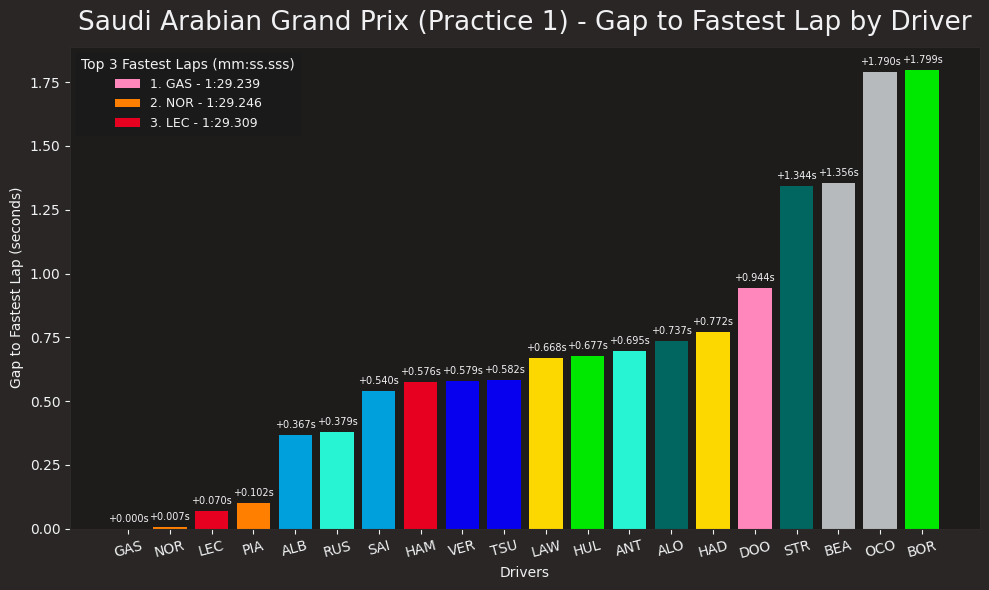

In [7]:
# Setup plotting
fastf1.plotting.setup_mpl(misc_mpl_mods=False, color_scheme='fastf1')

# Plotting
plt.figure(figsize=(10, 6))
bars = plt.bar(driver_names, lap_gaps, color=colors)
plt.ylabel('Gap to Fastest Lap (seconds)')
plt.xlabel('Drivers')
plt.title(f'{session.event['EventName']} ({session.name}) - Gap to Fastest Lap by Driver')
plt.xticks(fontsize=10, rotation=15)  

# Add text labels for each bar
for bar, gap in zip(bars, lap_gaps):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
             f"+{gap:.3f}s", ha='center', va='bottom', fontsize=7, rotation=0)

# Add legend with top 3 drivers in mm:ss.sss format
if legend_labels:  # Ensure legend_labels is not empty
    plt.legend(legend_handles, legend_labels, title="Top 3 Fastest Laps (mm:ss.sss)", 
               loc='upper left', fontsize=9, title_fontsize=10, ncol=1, frameon=True)

plt.tight_layout()
plt.show()

#### Lap Time

In [8]:
session = fastf1.get_session(2025, 'Jeddah', 'FP1')
session.load()

In [9]:
# Data containers
lap_times = []
driver_names = []
colors = []

# Collect fastest valid lap from each driver
for driver in session.drivers:
    driver_laps = session.laps.pick_drivers(driver)
    valid_laps = driver_laps.pick_accurate()

    if not valid_laps.empty:
        mean_lap_time = valid_laps['LapTime'].mean()
        lap_times.append(mean_lap_time.total_seconds())
        driver_names.append(driver_laps.iloc[0]['Driver'])
        driver_color = fastf1.plotting.get_driver_color(driver_laps.iloc[0]['Driver'], session) # fastf1.plotting.get_team_color(fastest_lap['Team'], session)
        colors.append(driver_color)

# Zip and sort
combined = sorted(zip(lap_times, driver_names, colors))
lap_times, driver_names, colors = zip(*combined)

# Calculate gaps to fastest lap
fastest_mean_lap_time = min(lap_times)
mean_lap_gaps = [t - fastest_mean_lap_time for t in lap_times]


# Format top 3 driver info for legend
legend_labels = []
legend_handles = []
for i in range(min(3, len(driver_names))):
    td = timedelta(seconds=lap_times[i])
    m, s = divmod(td.total_seconds(), 60)
    formatted = f"{int(m)}:{s:06.3f}"
    legend_labels.append(f"{i+1}. {driver_names[i]} - {formatted}")
    # Create proxy artists for the legend
    legend_handles.append(plt.Rectangle((0, 0), 1, 1, fc=colors[i]))

# Why Use Proxy Artists?
# The actual plot uses plt.bar(), but we want the legend to show only the top 3 drivers (not all bars).

# Proxy artists allow us to override the default legend and display custom entries.

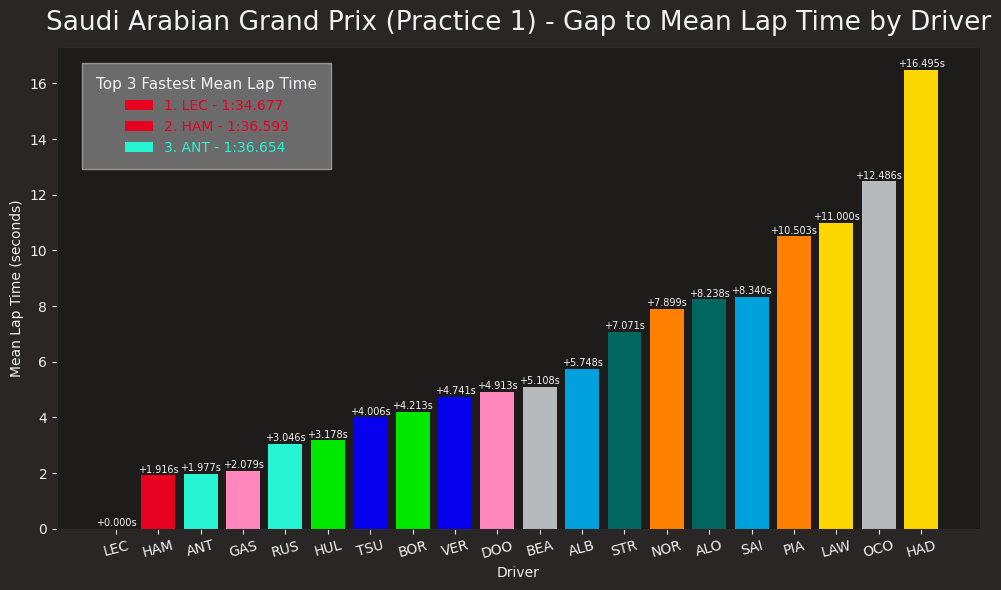

In [10]:
# Setup plotting
fastf1.plotting.setup_mpl(misc_mpl_mods=False, color_scheme='fastf1')

# Plotting
plt.figure(figsize=(10, 6))
bars = plt.bar(driver_names, mean_lap_gaps, color=colors)
plt.ylabel('Mean Lap Time (seconds)')
plt.xlabel('Driver')
plt.title(f'{session.event['EventName']} ({session.name}) - Gap to Mean Lap Time by Driver')
plt.xticks(fontsize=10, rotation=15)  
# plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.2)  # Modify these values as needed

# Add text labels for each bar
for bar, gap in zip(bars, mean_lap_gaps):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
             f"+{gap:.3f}s", ha='center', va='bottom', fontsize=7, rotation=0)

# Add legend with top 3 drivers in mm:ss.sss format
if legend_labels:  # Ensure legend_labels is not empty
    legend = plt.legend(legend_handles, legend_labels, title="Top 3 Fastest Mean Lap Time",
               loc='upper left', fontsize=10, title_fontsize=11, ncol=1, frameon=True,
               borderpad=1, bbox_to_anchor=(0.02, 0.98), facecolor='gray', 
               edgecolor='darkgray', framealpha=0.8)
    
    for text, color in zip(legend.get_texts(), colors[:3]):  
        text.set_color(color)  # Apply driver-specific color

    # legend.get_title().set_color("red")  

    # for text in legend.get_texts():
    #     text.set_color("black")  # Change "white" to any color you want

plt.tight_layout()
plt.show()



#### Speed Traces per Sector

In [11]:
# Understand where a driver is gaining/losing time during practice sessions.
# Compare Sector Time
# Look at the Telemetry data to understand the differences in driving style, throttle application,
# braking points, etc.

In [12]:
session = fastf1.get_session(2025, 'Jeddah', 'FP1')
session.load()

In [13]:
pd.set_option('display.max_columns', None)  # Show all columns in DataFrame

In [14]:
drv= 'NOR'

In [15]:
nor_lap = session.laps.pick_drivers(drv)
valid_laps = nor_lap[nor_lap['IsAccurate'] == True] 
valid_laps

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,Sector3Time,Sector1SessionTime,Sector2SessionTime,Sector3SessionTime,SpeedI1,SpeedI2,SpeedFL,SpeedST,IsPersonalBest,Compound,TyreLife,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
27,0 days 00:17:04.395000,NOR,4,0 days 00:01:31.887000,2.0,1.0,NaT,NaT,0 days 00:00:33.620000,0 days 00:00:28.954000,0 days 00:00:29.313000,0 days 00:16:06.128000,0 days 00:16:35.082000,0 days 00:17:04.395000,289.0,325.0,304.0,327.0,True,MEDIUM,2.0,True,McLaren,0 days 00:15:32.508000,2025-04-18 13:32:29.052,1,NaN,False,,False,True
28,0 days 00:19:33.268000,NOR,4,0 days 00:02:28.873000,3.0,1.0,NaT,NaT,0 days 00:00:48.045000,0 days 00:00:59.738000,0 days 00:00:41.090000,0 days 00:17:52.440000,0 days 00:18:52.178000,0 days 00:19:33.268000,171.0,94.0,302.0,158.0,False,MEDIUM,3.0,True,McLaren,0 days 00:17:04.395000,2025-04-18 13:34:00.939,1,NaN,False,,False,True
29,0 days 00:21:03.722000,NOR,4,0 days 00:01:30.454000,4.0,1.0,NaT,NaT,0 days 00:00:33.042000,0 days 00:00:28.498000,0 days 00:00:28.914000,0 days 00:20:06.310000,0 days 00:20:34.808000,0 days 00:21:03.722000,290.0,321.0,303.0,327.0,True,MEDIUM,4.0,True,McLaren,0 days 00:19:33.268000,2025-04-18 13:36:29.812,1,NaN,False,,False,True
30,0 days 00:23:32.533000,NOR,4,0 days 00:02:28.811000,5.0,1.0,NaT,NaT,0 days 00:00:51.907000,0 days 00:00:51.203000,0 days 00:00:45.701000,0 days 00:21:55.629000,0 days 00:22:46.832000,0 days 00:23:32.533000,159.0,149.0,302.0,150.0,False,MEDIUM,5.0,True,McLaren,0 days 00:21:03.722000,2025-04-18 13:38:00.266,1,NaN,False,,False,True
31,0 days 00:25:02.513000,NOR,4,0 days 00:01:29.980000,6.0,1.0,NaT,NaT,0 days 00:00:32.597000,0 days 00:00:28.468000,0 days 00:00:28.915000,0 days 00:24:05.130000,0 days 00:24:33.598000,0 days 00:25:02.513000,290.0,322.0,302.0,325.0,True,MEDIUM,6.0,True,McLaren,0 days 00:23:32.533000,2025-04-18 13:40:29.077,1,NaN,False,,False,True
34,0 days 00:43:05.110000,NOR,4,0 days 00:01:29.246000,9.0,2.0,NaT,NaT,0 days 00:00:32.322000,0 days 00:00:28.252000,0 days 00:00:28.672000,0 days 00:42:08.186000,0 days 00:42:36.438000,0 days 00:43:05.110000,290.0,322.0,303.0,322.0,True,SOFT,2.0,True,McLaren,0 days 00:41:35.864000,2025-04-18 13:58:32.408,1,NaN,False,,False,True
37,0 days 00:49:48.222000,NOR,4,0 days 00:01:32.845000,12.0,3.0,NaT,NaT,0 days 00:00:35.988000,0 days 00:00:28.206000,0 days 00:00:28.651000,0 days 00:48:51.365000,0 days 00:49:19.571000,0 days 00:49:48.222000,291.0,322.0,302.0,321.0,False,SOFT,5.0,False,McLaren,0 days 00:48:15.377000,2025-04-18 14:05:11.921,1,NaN,False,,False,True
40,0 days 01:00:58.222000,NOR,4,0 days 00:01:33.799000,15.0,4.0,NaT,NaT,0 days 00:00:34.354000,0 days 00:00:29.692000,0 days 00:00:29.753000,0 days 00:59:58.777000,0 days 01:00:28.469000,0 days 01:00:58.222000,283.0,299.0,290.0,304.0,False,MEDIUM,9.0,False,McLaren,0 days 00:59:24.423000,2025-04-18 14:16:20.967,1,NaN,False,,False,True
41,0 days 01:02:31.983000,NOR,4,0 days 00:01:33.761000,16.0,4.0,NaT,NaT,0 days 00:00:34.234000,0 days 00:00:29.570000,0 days 00:00:29.957000,0 days 01:01:32.456000,0 days 01:02:02.026000,0 days 01:02:31.983000,282.0,299.0,290.0,303.0,False,MEDIUM,10.0,False,McLaren,0 days 01:00:58.222000,2025-04-18 14:17:54.766,1,NaN,False,,False,True
42,0 days 01:04:05.391000,NOR,4,0 days 00:01:33.408000,17.0,4.0,NaT,NaT,0 days 00:00:34.101000,0 days 00:00:29.445000,0 days 00:00:29.862000,0 days 01:03:06.084000,0 days 01:03:35.529000,0 days 01:04:05.391000,285.0,296.0,290.0,306.0,False,MEDIUM,11.0,False,McLaren,0 days 01:02:31.983000,2025-04-18 14:19:28.527,1,NaN,False,,False,True


In [16]:
# Access all the laps in this session
laps = session.laps

# Pick a specific lap (e.g., the fastest lap)
fastest_lap = session.laps.pick_fastest()

# Now you can access telemetry or other data from the fastest lap
telemetry_data = fastest_lap.telemetry
telemetry_data 


,Date,SessionTime,DriverAhead,DistanceToDriverAhead,Time,RPM,Speed,nGear,Throttle,Brake,DRS,Source,Distance,RelativeDistance,Status,X,Y,Z
2,2025-04-18 14:05:38.201,0 days 00:48:41.657000,,919.878611,0 days 00:00:00,11061.195848,309.184509,8,100.0,False,12,interpolation,0.105919,0.000017,OnTrack,-1329.235075,321.929197,116.795617
3,2025-04-18 14:05:38.287,0 days 00:48:41.743000,,919.878611,0 days 00:00:00.086000,11091.756253,309.968109,8,100.0,False,12,pos,7.551595,0.001234,OnTrack,-1353.000000,387.000000,117.000000
4,2025-04-18 14:05:38.487,0 days 00:48:41.943000,,919.878611,0 days 00:00:00.286000,11162.826858,311.790432,8,100.0,False,12,pos,24.921933,0.004073,OnTrack,-1413.000000,549.000000,118.000000
5,2025-04-18 14:05:38.510,0 days 00:48:41.966000,,919.878611,0 days 00:00:00.309000,11171.000000,312.000000,8,100.0,False,12,car,26.924444,0.004400,OnTrack,-1422.594281,575.033680,117.992000
6,2025-04-18 14:05:38.670,0 days 00:48:42.126000,81,919.878611,0 days 00:00:00.469000,11186.000000,314.000000,8,100.0,False,12,car,40.880000,0.006681,OnTrack,-1500.878588,788.392979,117.159137
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
656,2025-04-18 14:07:07.087,0 days 00:50:10.543000,1,83.044444,0 days 00:01:28.886000,10942.333333,305.733333,8,100.0,False,12,pos,6086.298268,0.994615,OnTrack,-1224.000000,22.000000,118.000000
657,2025-04-18 14:07:07.111,0 days 00:50:10.567000,1,81.297778,0 days 00:01:28.910000,10949.000000,306.000000,8,100.0,False,12,car,6088.348333,0.994950,OnTrack,-1229.965050,39.510125,118.006966
658,2025-04-18 14:07:07.247,0 days 00:50:10.703000,1,81.297778,0 days 00:01:29.046000,10997.733333,307.133333,8,100.0,False,12,pos,6099.988828,0.996853,OnTrack,-1268.000000,151.000000,118.000000
659,2025-04-18 14:07:07.407,0 days 00:50:10.863000,1,81.297778,0 days 00:01:29.206000,11055.066667,308.466667,8,100.0,False,12,pos,6113.734579,0.999099,OnTrack,-1314.000000,280.000000,118.000000


In [17]:
session.laps.pick_fastest().telemetry.head()

,Date,SessionTime,DriverAhead,DistanceToDriverAhead,Time,RPM,Speed,nGear,Throttle,Brake,DRS,Source,Distance,RelativeDistance,Status,X,Y,Z
2,2025-04-18 14:05:38.201,0 days 00:48:41.657000,,919.878611,0 days 00:00:00,11061.195848,309.184509,8,100.0,False,12,interpolation,0.105919,0.000017,OnTrack,-1329.235075,321.929197,116.795617
3,2025-04-18 14:05:38.287,0 days 00:48:41.743000,,919.878611,0 days 00:00:00.086000,11091.756253,309.968109,8,100.0,False,12,pos,7.551595,0.001234,OnTrack,-1353.000000,387.000000,117.000000
4,2025-04-18 14:05:38.487,0 days 00:48:41.943000,,919.878611,0 days 00:00:00.286000,11162.826858,311.790432,8,100.0,False,12,pos,24.921933,0.004073,OnTrack,-1413.000000,549.000000,118.000000
5,2025-04-18 14:05:38.510,0 days 00:48:41.966000,,919.878611,0 days 00:00:00.309000,11171.000000,312.000000,8,100.0,False,12,car,26.924444,0.004400,OnTrack,-1422.594281,575.033680,117.992000
6,2025-04-18 14:05:38.670,0 days 00:48:42.126000,81,919.878611,0 days 00:00:00.469000,11186.000000,314.000000,8,100.0,False,12,car,40.880000,0.006681,OnTrack,-1500.878588,788.392979,117.159137


In [18]:
print(f'Fastest Sector 1 Lap No: {valid_laps.loc[valid_laps['Sector1Time'].idxmin(), 'LapNumber']}')
print(f'Sector 1 Time: {valid_laps['Sector1Time'].dt.total_seconds().min()}')
print(f'Fastest Sector 2 Lap No: {valid_laps.loc[valid_laps['Sector2Time'].idxmin(), 'LapNumber']}')
print(f'Sector 2 Time: {valid_laps['Sector2Time'].dt.total_seconds().min()}')
print(f'Fastest Sector 3 Lap No: {valid_laps.loc[valid_laps['Sector3Time'].idxmin(), 'LapNumber']}')
print(f'Sector 3 Time: {valid_laps['Sector3Time'].dt.total_seconds().min()}')
print(f'Fastest Lap Time: {valid_laps['LapTime'].dt.total_seconds().min()}')
print(f'Fastest Lap No: {valid_laps.loc[valid_laps['LapTime'].idxmin(), 'LapNumber']}')
print(f'Fastest Lap Sector 1 Time: {valid_laps.loc[valid_laps['LapTime'].idxmin(), 'Sector1Time'].total_seconds()}')
print(f'Fastest Lap Sector 2 Time: {valid_laps.loc[valid_laps['LapTime'].idxmin(), 'Sector2Time'].total_seconds()}')
print(f'Fastest Lap Sector 3 Time: {valid_laps.loc[valid_laps['LapTime'].idxmin(), 'Sector3Time'].total_seconds()}')


Fastest Sector 1 Lap No: 9.0
Sector 1 Time: 32.322
Fastest Sector 2 Lap No: 12.0
Sector 2 Time: 28.206
Fastest Sector 3 Lap No: 12.0
Sector 3 Time: 28.651
Fastest Lap Time: 89.246
Fastest Lap No: 9.0
Fastest Lap Sector 1 Time: 32.322
Fastest Lap Sector 2 Time: 28.252
Fastest Lap Sector 3 Time: 28.672


Text(0, 0.5, 'Sector 1 Time (seconds)')

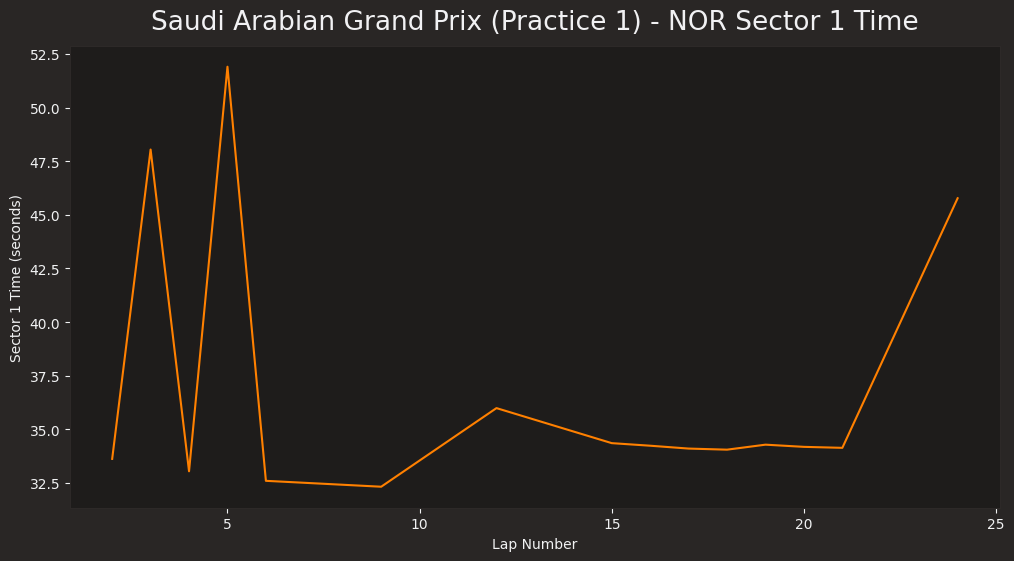

In [19]:
plt.figure(figsize=(12, 6))
plt.plot(valid_laps['LapNumber'], valid_laps['Sector1Time'].dt.total_seconds(),
             label=drv, color=fastf1.plotting.get_driver_color(drv, session))
plt.title(f'{session.event['EventName']} ({session.name}) - NOR Sector 1 Time')
plt.xlabel('Lap Number')
plt.ylabel('Sector 1 Time (seconds)')

##### Speed Trace

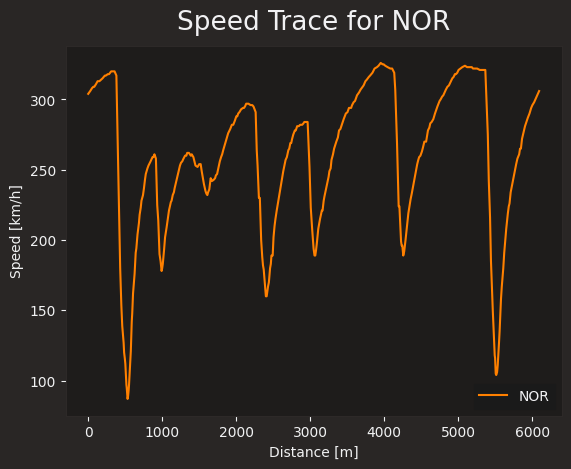

In [20]:
nor_lap = session.laps.pick_drivers('NOR').pick_fastest()  # Select fastest lap for NOR
nor_tel = nor_lap.get_car_data().add_distance()  # Get telemetry data

# Set the color and label for NOR
nor_color = fastf1.plotting.get_driver_color('NOR', session)  # Get the color for NOR

# Plot the data
plt.plot(nor_tel['Distance'], nor_tel['Speed'], color=nor_color, label='NOR')  # Update label and color
plt.xlabel("Distance [m]")
plt.ylabel("Speed [km/h]")
plt.legend()
plt.title("Speed Trace for NOR")
plt.show()

#### Comparing Car Setup High or Low Downforce

In [21]:
# Load the session and data
session = fastf1.get_session(2025, 'Monza', 'FP2')  
session.load()


In [22]:
# Compare two drivers (e.g. VER and LEC)
ver_lap = session.laps.pick_drivers('VER').pick_fastest()
lec_lap = session.laps.pick_drivers('LEC').pick_fastest()

# Get telemetry
ver_tel = ver_lap.get_car_data().add_distance()
lec_tel = lec_lap.get_car_data().add_distance()


In [23]:
ver_top_speed = ver_tel['Speed'].max()
lec_top_speed = lec_tel['Speed'].max()

print(f"VER Top Speed: {ver_top_speed:.2f} km/h")
print(f"LEC Top Speed: {lec_top_speed:.2f} km/h")


VER Top Speed: 341.00 km/h
LEC Top Speed: 344.00 km/h


In [24]:
# NOTE: The distance range (2000–2300m) is an example for corner analysis.
# Adjust the range based on the specific track and corner you want to analyse.
ver_lesmo2 = ver_tel[(ver_tel['Distance'] > 2000) & (ver_tel['Distance'] < 2300)]
lec_lesmo2 = lec_tel[(lec_tel['Distance'] > 2000) & (lec_tel['Distance'] < 2300)]

print(f"VER Corner Speed (avg): {ver_lesmo2['Speed'].mean():.2f} km/h")
print(f"LEC Corner Speed (avg): {lec_lesmo2['Speed'].mean():.2f} km/h")


VER Corner Speed (avg): 167.04 km/h
LEC Corner Speed (avg): 160.80 km/h


In [25]:
ver_lesmo2

,Date,RPM,Speed,nGear,Throttle,Brake,DRS,Source,Time,SessionTime,Distance
108,2025-09-05 15:36:29.462,10688.0,313.0,8,0.0,True,8,car,0 days 00:00:28.058000,0 days 00:51:23.259000,2015.335833
109,2025-09-05 15:36:29.702,10191.0,281.0,8,0.0,True,8,car,0 days 00:00:28.298000,0 days 00:51:23.499000,2034.069167
110,2025-09-05 15:36:29.942,9715.0,234.0,8,0.0,True,8,car,0 days 00:00:28.538000,0 days 00:51:23.739000,2049.669167
111,2025-09-05 15:36:30.262,9378.0,193.0,6,0.0,True,8,car,0 days 00:00:28.858000,0 days 00:51:24.059000,2066.824722
112,2025-09-05 15:36:30.542,9498.0,160.0,5,0.0,True,8,car,0 days 00:00:29.138000,0 days 00:51:24.339000,2079.269167
113,2025-09-05 15:36:30.782,10498.0,146.0,4,0.0,True,8,car,0 days 00:00:29.378000,0 days 00:51:24.579000,2089.002500
114,2025-09-05 15:36:30.982,9317.0,136.0,3,0.0,True,8,car,0 days 00:00:29.578000,0 days 00:51:24.779000,2096.558056
115,2025-09-05 15:36:31.262,8867.0,124.0,3,0.0,True,8,car,0 days 00:00:29.858000,0 days 00:51:25.059000,2106.202500
116,2025-09-05 15:36:31.462,8422.0,118.0,3,0.0,True,8,car,0 days 00:00:30.058000,0 days 00:51:25.259000,2112.758056
117,2025-09-05 15:36:31.622,7954.0,115.0,3,0.0,True,8,car,0 days 00:00:30.218000,0 days 00:51:25.419000,2117.869167


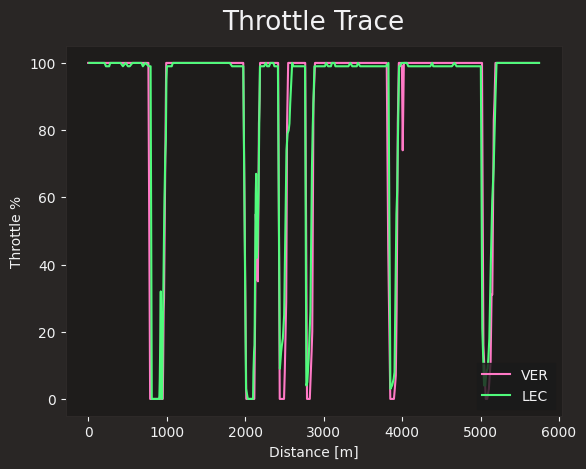

In [26]:
# Setup plotting
fastf1.plotting.setup_mpl(misc_mpl_mods=False, color_scheme='fastf1')

plt.plot(ver_tel['Distance'], ver_tel['Throttle'], label='VER')
plt.plot(lec_tel['Distance'], lec_tel['Throttle'], label='LEC')
plt.xlabel("Distance [m]")
plt.ylabel("Throttle %")
plt.legend(loc="lower right")
plt.title("Throttle Trace")
plt.show()


In [27]:
print(f"VER lower top speed, higher corner speed, more stable throttle application. Higher downforce setting")
print(f"LEC higher top speed, lower corner speed, more throttle modulation. Lower downforce setting")

VER lower top speed, higher corner speed, more stable throttle application. Higher downforce setting
LEC higher top speed, lower corner speed, more throttle modulation. Lower downforce setting


#### Throttle & Brake Overlay

In [28]:
# Compare drivers’ control inputs to prepare better for qualifying pace.

In [29]:
# Load the session and data
session = fastf1.get_session(2025, 'Spain', 'FP2') 
session.load()

In [30]:
session.laps.head()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,Sector3Time,Sector1SessionTime,Sector2SessionTime,Sector3SessionTime,SpeedI1,SpeedI2,SpeedFL,SpeedST,IsPersonalBest,Compound,TyreLife,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,0 days 00:20:24.214000,VER,1,NaT,1.0,1.0,0 days 00:18:45.392000,NaT,NaT,0 days 00:00:40.032000,0 days 00:00:27.982000,NaT,0 days 00:19:56.477000,0 days 00:20:24.297000,184.0,177.0,291.0,219.0,False,MEDIUM,1.0,True,Red Bull Racing,0 days 00:18:45.392000,2025-05-30 15:03:45.403,1,NaN,False,,False,False
1,0 days 00:21:38.124000,VER,1,0 days 00:01:13.910000,2.0,1.0,NaT,NaT,0 days 00:00:21.790000,0 days 00:00:29.750000,0 days 00:00:22.370000,0 days 00:20:46.004000,0 days 00:21:15.754000,0 days 00:21:38.124000,291.0,307.0,293.0,327.0,True,MEDIUM,2.0,True,Red Bull Racing,0 days 00:20:24.214000,2025-05-30 15:05:24.225,1,NaN,False,,False,True
2,0 days 00:24:05.762000,VER,1,0 days 00:02:27.638000,3.0,1.0,NaT,0 days 00:24:03.008000,0 days 00:00:45.403000,0 days 00:00:58.373000,0 days 00:00:43.862000,0 days 00:22:23.527000,0 days 00:23:21.900000,0 days 00:24:05.762000,128.0,124.0,NaN,129.0,False,MEDIUM,3.0,True,Red Bull Racing,0 days 00:21:38.124000,2025-05-30 15:06:38.135,1,NaN,False,,False,False
3,0 days 00:26:16.708000,VER,1,0 days 00:02:10.946000,4.0,2.0,0 days 00:24:27.863000,NaT,0 days 00:00:56.794000,0 days 00:00:48.939000,0 days 00:00:25.213000,0 days 00:25:02.556000,0 days 00:25:51.495000,0 days 00:26:16.708000,138.0,245.0,291.0,206.0,False,MEDIUM,4.0,False,Red Bull Racing,0 days 00:24:05.762000,2025-05-30 15:09:05.773,12,NaN,False,,False,False
4,0 days 00:27:41.658000,VER,1,0 days 00:01:24.950000,5.0,2.0,NaT,0 days 00:27:38.809000,0 days 00:00:21.832000,0 days 00:00:29.837000,0 days 00:00:33.281000,0 days 00:26:38.540000,0 days 00:27:08.377000,0 days 00:27:41.658000,291.0,309.0,NaN,326.0,False,MEDIUM,5.0,False,Red Bull Racing,0 days 00:26:16.708000,2025-05-30 15:11:16.719,1,NaN,False,,False,False


In [31]:
ver = "VER"
lec = "LEC"

# Compare two drivers (e.g. VER and LEC)
ver_lap = session.laps.pick_drivers(ver).pick_fastest()
lec_lap = session.laps.pick_drivers(lec).pick_fastest()

# Get telemetry
ver_tel = ver_lap.get_car_data().add_distance()
lec_tel = lec_lap.get_car_data().add_distance()


In [32]:
ver_tel

,Date,RPM,Speed,nGear,Throttle,Brake,DRS,Source,Time,SessionTime,Distance
0,2025-05-30 15:23:28.517,10664.0,299.0,8,100.0,False,12,car,0 days 00:00:00.072000,0 days 00:38:28.506000,5.980000
1,2025-05-30 15:23:28.756,10742.0,303.0,8,100.0,False,12,car,0 days 00:00:00.311000,0 days 00:38:28.745000,26.095833
2,2025-05-30 15:23:29.156,10882.0,306.0,8,100.0,False,12,car,0 days 00:00:00.711000,0 days 00:38:29.145000,60.095833
3,2025-05-30 15:23:29.516,10939.0,308.0,8,100.0,False,12,car,0 days 00:00:01.071000,0 days 00:38:29.505000,90.895833
4,2025-05-30 15:23:29.956,11083.0,312.0,8,100.0,False,12,car,0 days 00:00:01.511000,0 days 00:38:29.945000,129.029167
...,...,...,...,...,...,...,...,...,...,...,...
265,2025-05-30 15:24:39.476,11121.0,279.0,7,100.0,False,8,car,0 days 00:01:11.031000,0 days 00:39:39.465000,4470.644722
266,2025-05-30 15:24:39.756,11189.0,282.0,7,100.0,False,8,car,0 days 00:01:11.311000,0 days 00:39:39.745000,4492.578056
267,2025-05-30 15:24:39.917,11206.0,283.0,7,100.0,False,8,car,0 days 00:01:11.472000,0 days 00:39:39.906000,4505.234444
268,2025-05-30 15:24:40.157,11274.0,285.0,7,100.0,False,8,car,0 days 00:01:11.712000,0 days 00:39:40.146000,4524.234444


In [33]:
ver_tel['Brake']

0      False
1      False
2      False
3      False
4      False
       ...  
265    False
266    False
267    False
268    False
269    False
Name: Brake, Length: 270, dtype: bool

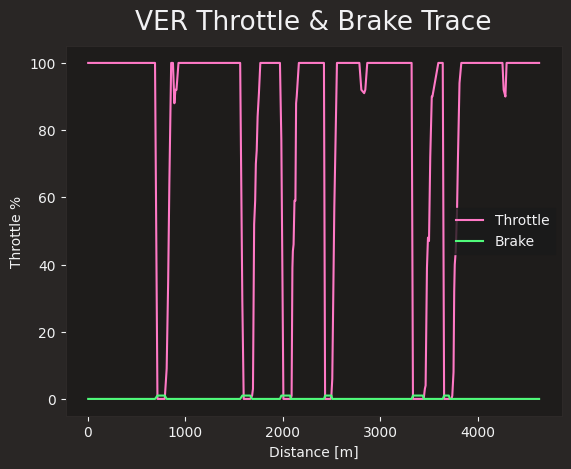

In [34]:
# Setup plotting
fastf1.plotting.setup_mpl(misc_mpl_mods=False, color_scheme='fastf1')

plt.plot(ver_tel['Distance'], ver_tel['Throttle'], label='Throttle')
plt.plot(ver_tel['Distance'], ver_tel['Brake'], label='Brake')
plt.xlabel("Distance [m]")
plt.ylabel("Throttle %")
plt.legend(loc="right")
plt.title(ver + " Throttle & Brake Trace")
plt.show()

# Brake data is only 0 and 1 

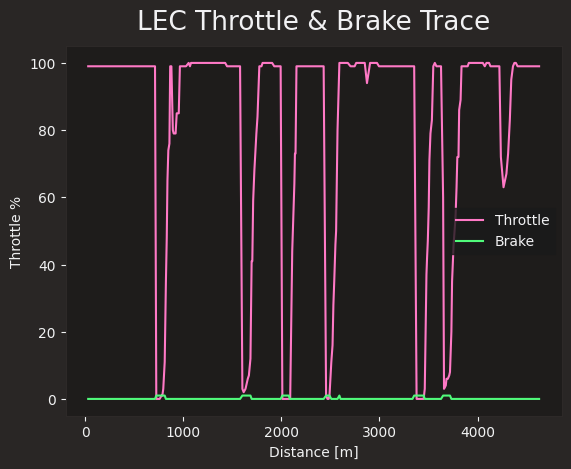

In [35]:
# Setup plotting
fastf1.plotting.setup_mpl(misc_mpl_mods=False, color_scheme='fastf1')

plt.plot(lec_tel['Distance'], lec_tel['Throttle'], label='Throttle')
plt.plot(lec_tel['Distance'], lec_tel['Brake'], label='Brake')
plt.xlabel("Distance [m]")
plt.ylabel("Throttle %")
plt.legend(loc="right")
plt.title(lec + " Throttle & Brake Trace")
plt.show()


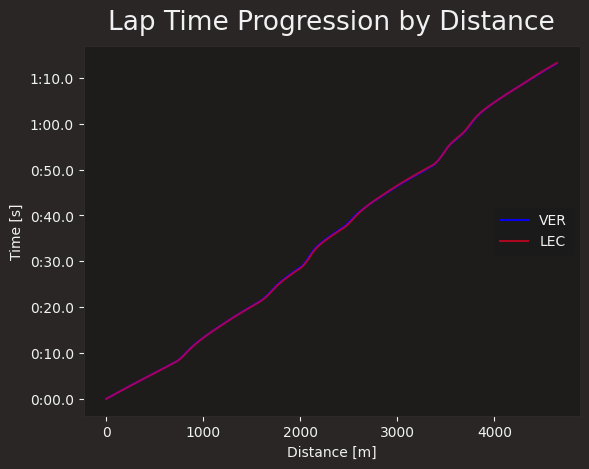

In [ ]:
# Setup plotting
fastf1.plotting.setup_mpl(misc_mpl_mods=False, color_scheme='fastf1')

ver_color = fastf1.plotting.get_driver_color(ver_lap['Driver'], session)
lec_color = fastf1.plotting.get_driver_color(lec_lap['Driver'], session)

plt.plot(ver_lap.get_telemetry()['Distance'], ver_lap.get_telemetry()['Time'], color=ver_color, label='VER')
plt.plot(lec_lap.get_telemetry()['Distance'], lec_lap.get_telemetry()['Time'], color=lec_color, label='LEC', alpha=0.6)
plt.xlabel("Distance [m]")
plt.ylabel("Time [s]")
plt.legend(loc="right")
plt.title("Lap Time Progression by Distance")
plt.show()


In [37]:
# get telemetry and sector time
tel = ver_lap.get_telemetry().reset_index(drop=True)   # telemetry DataFrame
sector1_time = ver_lap['Sector1Time']                   # Timedelta
sector2_time = ver_lap['Sector2Time']                   # Timedelta
sector3_time = ver_lap['Sector3Time']                   # Timedelta

def get_sector_distance(telemetry, sector_time):
    """Return the distance at which a sector ends."""
    idx = (telemetry['Time'] - sector_time).abs().idxmin()
    return telemetry.loc[idx, ['Time', 'Distance']]

# Get distances for each sector
sec1 = get_sector_distance(tel, sector1_time)
sec2 = get_sector_distance(tel, sector1_time + sector2_time)
sec3 = get_sector_distance(tel, sector1_time + sector2_time + sector3_time)

print("Sector 1 end:", sec1)
print("Sector 2 end:", sec2)
print("Sector 3 end:", sec3)

Sector 1 end: Time        0 days 00:00:21.694000
Distance               1611.378754
Name: 167, dtype: object
Sector 2 end: Time        0 days 00:00:50.871000
Distance               3365.685278
Name: 389, dtype: object
Sector 3 end: Time        0 days 00:01:13.070000
Distance               4634.917465
Name: 544, dtype: object


In [38]:
# Row with closest Time to Sector1Time
closest_idx = (tel['Time'] - sector1_time).abs().idxmin()
closest_row = tel.loc[closest_idx]
print("Closest telemetry row to Sector1Time (index, time):", closest_idx, closest_row['Time'])
display(closest_row['Distance'])


Closest telemetry row to Sector1Time (index, time): 167 0 days 00:00:21.694000


np.float64(1611.378754194652)

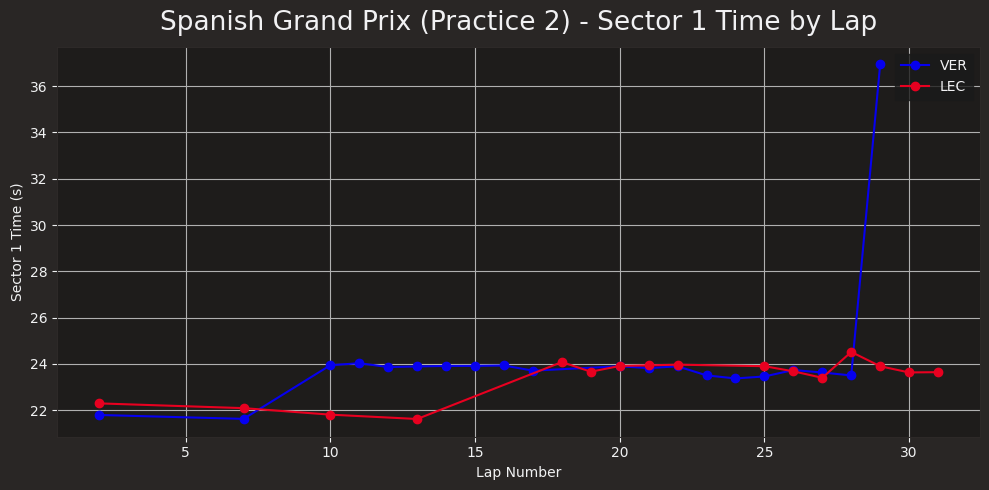

In [39]:
# Plot Sector 1 times per lap for two drivers (fixed)
drivers = ['VER', 'LEC']

# Setup plotting
fastf1.plotting.setup_mpl(misc_mpl_mods=False, color_scheme='fastf1')

plt.figure(figsize=(10,5))
for drv in drivers:
    laps_drv = session.laps.pick_drivers(drv).pick_accurate()  # DataFrame of laps
    if laps_drv.empty:
        continue
    laps_drv = laps_drv.sort_values('LapNumber')
    laps_drv = laps_drv[laps_drv['Sector1Time'].notna()]      # remove missing sector times
    lap_nums = laps_drv['LapNumber']
    s1 = laps_drv['Sector1Time'].dt.total_seconds()           # convert timedelta to seconds
    plt.plot(lap_nums, s1, marker='o', label=drv,
             color=fastf1.plotting.get_driver_color(drv, session))

plt.xlabel("Lap Number")
plt.ylabel("Sector 1 Time (s)")
plt.title(f"{session.event['EventName']} ({session.name}) - Sector 1 Time by Lap")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


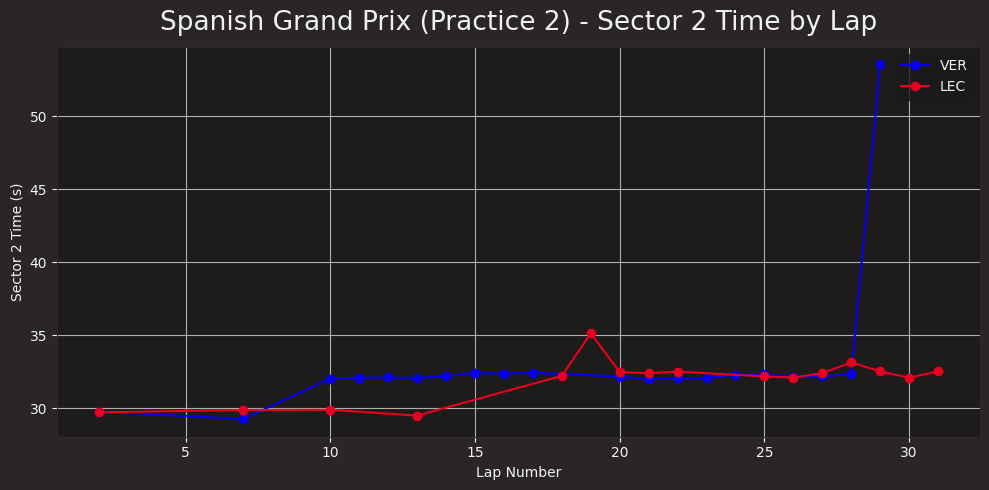

In [40]:
# Plot Sector 2 times per lap for two drivers (fixed)
drivers = ['VER', 'LEC']

plt.figure(figsize=(10,5))
for drv in drivers:
    laps_drv = session.laps.pick_drivers(drv).pick_accurate()  # DataFrame of laps
    if laps_drv.empty:
        continue
    laps_drv = laps_drv.sort_values('LapNumber')
    laps_drv = laps_drv[laps_drv['Sector2Time'].notna()]      # remove missing sector times
    lap_nums = laps_drv['LapNumber']
    s2 = laps_drv['Sector2Time'].dt.total_seconds()           # convert timedelta to seconds
    plt.plot(lap_nums, s2, marker='o', label=drv,
             color=fastf1.plotting.get_driver_color(drv, session))

plt.xlabel("Lap Number")
plt.ylabel("Sector 2 Time (s)")
plt.title(f"{session.event['EventName']} ({session.name}) - Sector 2 Time by Lap")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


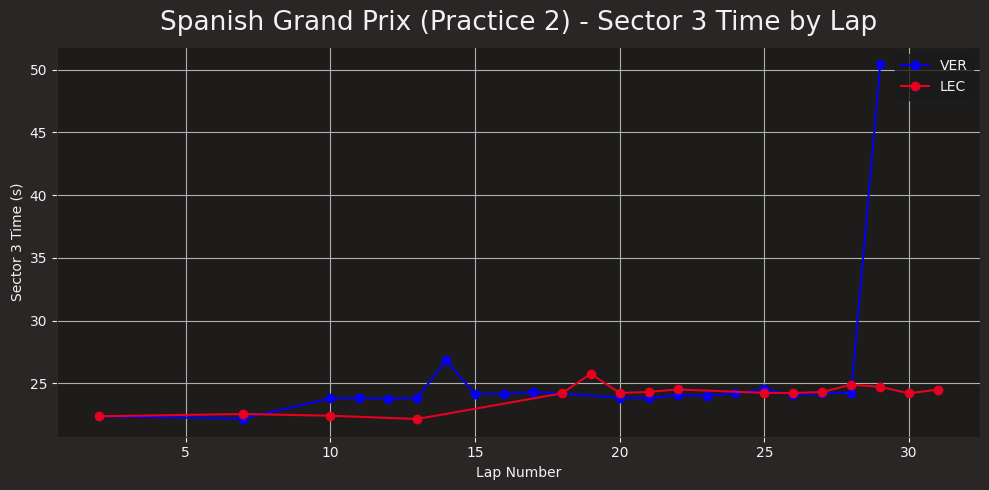

In [41]:
# Plot Sector 3 times per lap for two drivers (fixed)
drivers = ['VER', 'LEC']

plt.figure(figsize=(10,5))
for drv in drivers:
    laps_drv = session.laps.pick_drivers(drv).pick_accurate()  # DataFrame of laps
    if laps_drv.empty:
        continue
    laps_drv = laps_drv.sort_values('LapNumber')
    laps_drv = laps_drv[laps_drv['Sector3Time'].notna()]      # remove missing sector times
    lap_nums = laps_drv['LapNumber']
    s3 = laps_drv['Sector3Time'].dt.total_seconds()           # convert timedelta to seconds
    plt.plot(lap_nums, s3, marker='o', label=drv,
             color=fastf1.plotting.get_driver_color(drv, session))

plt.xlabel("Lap Number")
plt.ylabel("Sector 3 Time (s)")
plt.title(f"{session.event['EventName']} ({session.name}) - Sector 3 Time by Lap")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Strategy & Track Condition Forecasting

#### Tyre Compound Analysis

In [42]:
# Objective: Compare race pace by averaging lap times in high-fuel conditions.

##### Short-Run Compound Performance (Quali Pace)

In [43]:
session = fastf1.get_session(2025, 'Spain', 'FP2')  # Use FP2 (race sims)
session.load()


In [44]:
session.laps.columns

Index(['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint',
       'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time',
       'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
       'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest',
       'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime',
       'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason',
       'FastF1Generated', 'IsAccurate'],
      dtype='object')

In [45]:
tyre_cmpd = 'SOFT'
tyre_life = 3

# Start with the filtered laps: accurate laps on SOFT compounds
accurate_laps = session.laps.pick_accurate().pick_compounds(tyre_cmpd)

# Further filter to only include laps where TyreLife < 3
fresh_laps = accurate_laps[accurate_laps['TyreLife'] < tyre_life]
best_fresh_laps = fresh_laps[fresh_laps['IsPersonalBest'] == True]
best_fresh_laps = best_fresh_laps[['Driver', 'DriverNumber', 'Team', 'LapNumber', 'LapTime', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST']]

time_cols = ['LapTime', 'Sector1Time', 'Sector2Time', 'Sector3Time']
for col in time_cols:
    best_fresh_laps[f'{col}_s'] = best_fresh_laps[col].dt.total_seconds()

ranked_laps = best_fresh_laps.reset_index(drop='TRUE').sort_values('LapTime')
ranked_laps

,Driver,DriverNumber,Team,LapNumber,LapTime,Sector1Time,Sector2Time,Sector3Time,SpeedI1,SpeedI2,SpeedFL,SpeedST,LapTime_s,Sector1Time_s,Sector2Time_s,Sector3Time_s
18,PIA,81,McLaren,8.0,0 days 00:01:12.760000,0 days 00:00:21.501000,0 days 00:00:29.198000,0 days 00:00:22.061000,293.0,312.0,292.0,327.0,72.760,21.501,29.198,22.061
17,RUS,63,Mercedes,8.0,0 days 00:01:13.046000,0 days 00:00:21.722000,0 days 00:00:29.235000,0 days 00:00:22.089000,289.0,307.0,292.0,323.0,73.046,21.722,29.235,22.089
0,VER,1,Red Bull Racing,7.0,0 days 00:01:13.070000,0 days 00:00:21.621000,0 days 00:00:29.254000,0 days 00:00:22.195000,291.0,310.0,291.0,325.0,73.070,21.621,29.254,22.195
1,NOR,4,McLaren,8.0,0 days 00:01:13.070000,0 days 00:00:21.542000,0 days 00:00:29.331000,0 days 00:00:22.197000,292.0,309.0,292.0,326.0,73.070,21.542,29.331,22.197
7,LEC,16,Ferrari,13.0,0 days 00:01:13.260000,0 days 00:00:21.616000,0 days 00:00:29.488000,0 days 00:00:22.156000,294.0,310.0,292.0,325.0,73.260,21.616,29.488,22.156
5,ANT,12,Mercedes,8.0,0 days 00:01:13.298000,0 days 00:00:21.725000,0 days 00:00:29.343000,0 days 00:00:22.230000,288.0,306.0,290.0,323.0,73.298,21.725,29.343,22.230
6,ALO,14,Aston Martin,11.0,0 days 00:01:13.301000,0 days 00:00:21.766000,0 days 00:00:29.350000,0 days 00:00:22.185000,289.0,305.0,284.0,322.0,73.301,21.766,29.350,22.185
4,GAS,10,Alpine,10.0,0 days 00:01:13.385000,0 days 00:00:21.802000,0 days 00:00:29.437000,0 days 00:00:22.146000,290.0,307.0,292.0,325.0,73.385,21.802,29.437,22.146
3,HAD,6,Racing Bulls,11.0,0 days 00:01:13.400000,0 days 00:00:21.823000,0 days 00:00:29.367000,0 days 00:00:22.210000,288.0,307.0,289.0,323.0,73.400,21.823,29.367,22.210
12,LAW,30,Racing Bulls,11.0,0 days 00:01:13.494000,0 days 00:00:21.837000,0 days 00:00:29.447000,0 days 00:00:22.210000,289.0,307.0,292.0,324.0,73.494,21.837,29.447,22.210


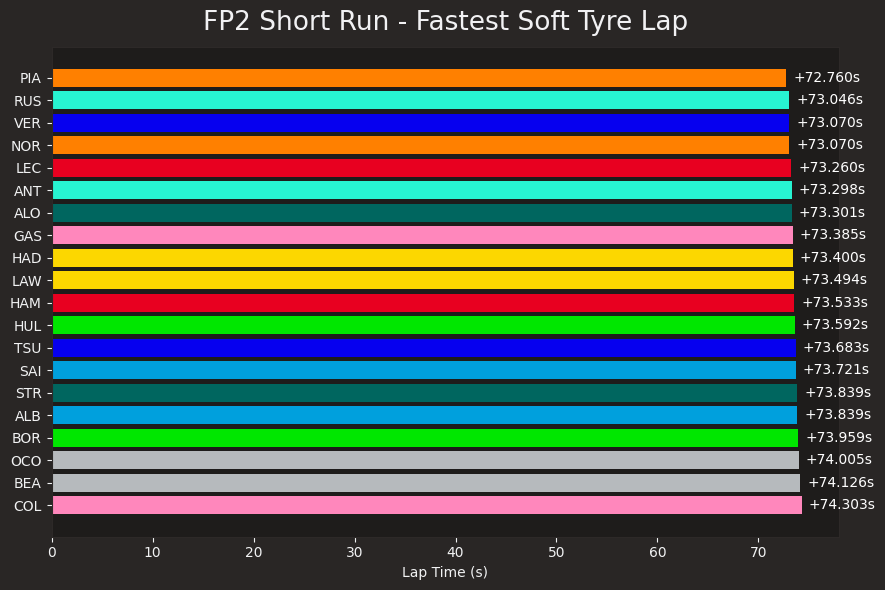

In [86]:
# Setup plotting
fastf1.plotting.setup_mpl(misc_mpl_mods=False, color_scheme='fastf1')

# Get driver colors for each driver in ranked_laps
driver_colors = [fastf1.plotting.get_driver_color(drv, session) for drv in ranked_laps['Driver']]

fig, ax = plt.subplots(figsize=(9,6))
bars = ax.barh(ranked_laps['Driver'], ranked_laps['LapTime_s'], color=driver_colors)

# Annotate lap time labels to the right of each bar
lap_labels = [f"+{lap:.3f}s" for lap in ranked_laps['LapTime_s']]
ax.bar_label(bars, labels=lap_labels, padding=5, label_type='edge', color='white')

ax.set_xlabel('Lap Time (s)')
ax.set_title('FP2 Short Run - Fastest Soft Tyre Lap')
ax.invert_yaxis()  # fastest at top
plt.tight_layout()
plt.show()


In [47]:
best_time = ranked_laps['LapTime_s'].min()

ranked_laps['Delta_s'] = ranked_laps['LapTime_s'] - best_time
ranked_laps

,Driver,DriverNumber,Team,LapNumber,LapTime,Sector1Time,Sector2Time,Sector3Time,SpeedI1,SpeedI2,SpeedFL,SpeedST,LapTime_s,Sector1Time_s,Sector2Time_s,Sector3Time_s,Delta_s
18,PIA,81,McLaren,8.0,0 days 00:01:12.760000,0 days 00:00:21.501000,0 days 00:00:29.198000,0 days 00:00:22.061000,293.0,312.0,292.0,327.0,72.760,21.501,29.198,22.061,0.000
17,RUS,63,Mercedes,8.0,0 days 00:01:13.046000,0 days 00:00:21.722000,0 days 00:00:29.235000,0 days 00:00:22.089000,289.0,307.0,292.0,323.0,73.046,21.722,29.235,22.089,0.286
0,VER,1,Red Bull Racing,7.0,0 days 00:01:13.070000,0 days 00:00:21.621000,0 days 00:00:29.254000,0 days 00:00:22.195000,291.0,310.0,291.0,325.0,73.070,21.621,29.254,22.195,0.310
1,NOR,4,McLaren,8.0,0 days 00:01:13.070000,0 days 00:00:21.542000,0 days 00:00:29.331000,0 days 00:00:22.197000,292.0,309.0,292.0,326.0,73.070,21.542,29.331,22.197,0.310
7,LEC,16,Ferrari,13.0,0 days 00:01:13.260000,0 days 00:00:21.616000,0 days 00:00:29.488000,0 days 00:00:22.156000,294.0,310.0,292.0,325.0,73.260,21.616,29.488,22.156,0.500
5,ANT,12,Mercedes,8.0,0 days 00:01:13.298000,0 days 00:00:21.725000,0 days 00:00:29.343000,0 days 00:00:22.230000,288.0,306.0,290.0,323.0,73.298,21.725,29.343,22.230,0.538
6,ALO,14,Aston Martin,11.0,0 days 00:01:13.301000,0 days 00:00:21.766000,0 days 00:00:29.350000,0 days 00:00:22.185000,289.0,305.0,284.0,322.0,73.301,21.766,29.350,22.185,0.541
4,GAS,10,Alpine,10.0,0 days 00:01:13.385000,0 days 00:00:21.802000,0 days 00:00:29.437000,0 days 00:00:22.146000,290.0,307.0,292.0,325.0,73.385,21.802,29.437,22.146,0.625
3,HAD,6,Racing Bulls,11.0,0 days 00:01:13.400000,0 days 00:00:21.823000,0 days 00:00:29.367000,0 days 00:00:22.210000,288.0,307.0,289.0,323.0,73.400,21.823,29.367,22.210,0.640
12,LAW,30,Racing Bulls,11.0,0 days 00:01:13.494000,0 days 00:00:21.837000,0 days 00:00:29.447000,0 days 00:00:22.210000,289.0,307.0,292.0,324.0,73.494,21.837,29.447,22.210,0.734


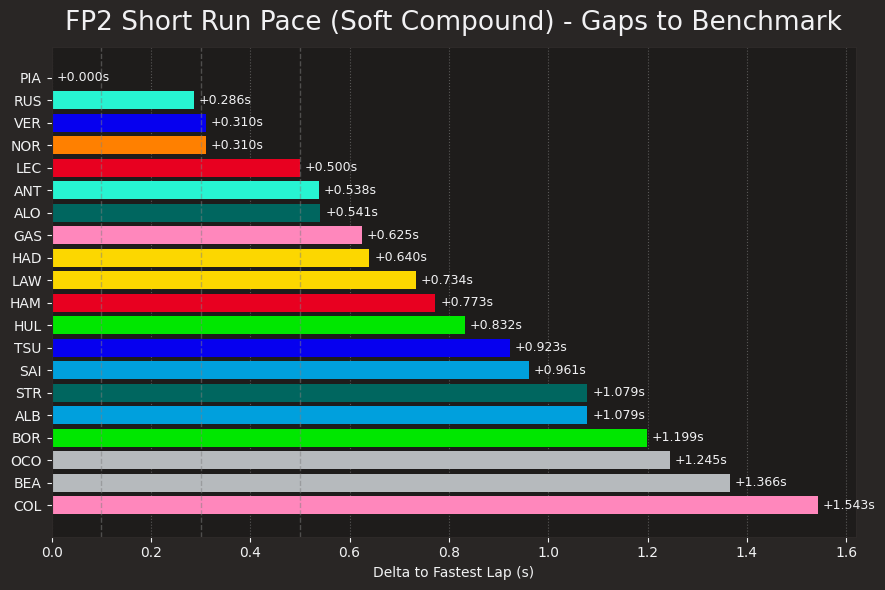

In [87]:
# Setup plotting
fastf1.plotting.setup_mpl(misc_mpl_mods=False, color_scheme='fastf1')

# Driver colors
driver_colors = [
    fastf1.plotting.get_driver_color(drv, session)
    for drv in ranked_laps['Driver']
]

# Sort by delta (safety check)
ranked_laps = ranked_laps.sort_values('Delta_s')

plt.figure(figsize=(9, 6))

bars = plt.barh(
    ranked_laps['Driver'],
    ranked_laps['Delta_s'],
    color=driver_colors
)

plt.xlabel('Delta to Fastest Lap (s)')
plt.title('FP2 Short Run Pace (Soft Compound) - Gaps to Benchmark')

# Invert Y-axis so fastest is on top
plt.gca().invert_yaxis()

# Performance windows (engineering thresholds)
plt.axvline(0.1, linestyle='--', linewidth=1, color='gray', alpha=0.5)
plt.axvline(0.3, linestyle='--', linewidth=1, color='gray', alpha=0.5)
plt.axvline(0.5, linestyle='--', linewidth=1, color='gray', alpha=0.5)

# Add delta labels at end of bars
for bar in bars:
    delta = bar.get_width()
    plt.text(
        delta + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"+{delta:.3f}s",
        va='center',
        fontsize=9
    )

# Grid only on x-axis (clean, readable)
plt.grid(axis='x', linestyle=':', alpha=0.4)

# Tight layout for report export
plt.tight_layout()

plt.show()


##### Long-Run Compound Performance (Race Pace)

Summary of Long Run Laps

In [49]:
session = fastf1.get_session(2025, 'Spain', 'FP2')  # Use FP2 (race sims)
session.load()


In [50]:
accurate_laps = session.laps.pick_accurate().dropna(subset=['LapTime'])
accurate_laps = accurate_laps[['Driver', 'DriverNumber', 'Team', 'LapTime', 'LapNumber', 'Stint','Compound', 'TyreLife']]

group_cols = ['Driver', 'Compound', 'Stint']
min_lap = 5

def is_valid_long_run(stint):
    return (
        len(stint) >= min_lap and
        stint['LapNumber'].is_monotonic_increasing and
        stint['LapNumber'].diff().dropna().eq(1).all()
    )

long_runs = (
    accurate_laps
    .groupby(group_cols, group_keys=False)
    .filter(is_valid_long_run)
)



time_cols = ['LapTime']
for col in time_cols:
    long_runs[f'{col}_s'] = long_runs[col].dt.total_seconds()

long_runs

summary = (
    long_runs
    .groupby(['Driver', 'Compound'])
    .agg(
        AvgLap=('LapTime_s', 'mean'),
        MedianLap=('LapTime_s', 'median'),
        Degradation=('LapTime_s', lambda x: x.diff().mean()),
        Consistency=('LapTime_s', 'std'),
        Laps=('LapNumber', 'count')
    )
    .reset_index()
)
summary

,Driver,Compound,AvgLap,MedianLap,Degradation,Consistency,Laps
0,ALB,SOFT,85.014167,81.0290,4.165273,13.190940,12
1,ALO,MEDIUM,110.081571,123.0490,0.097500,30.252590,7
2,ALO,SOFT,81.488273,80.9450,-0.022500,1.901502,11
3,ANT,SOFT,81.565000,81.2400,0.163143,1.429027,15
4,BEA,SOFT,86.795400,81.7510,4.957333,14.845781,10
5,BOR,SOFT,81.240091,81.0750,0.223400,0.671830,11
6,COL,HARD,85.264889,81.0560,4.713000,12.459436,9
7,GAS,MEDIUM,86.941375,80.3475,7.573714,18.707784,8
8,GAS,SOFT,80.337400,80.2860,0.335500,0.560782,5
9,HAD,SOFT,81.318364,81.0020,-0.042500,1.444047,11


Lap Time vs Tyre degradation Analysis

In [51]:
long_runs_deg = long_runs.copy()

long_runs_deg['LapInStint'] = (
    long_runs_deg
    .groupby(['Driver', 'Compound', 'Stint'])
    .cumcount() + 1
)
long_runs_deg

,Driver,DriverNumber,Team,LapTime,LapNumber,Stint,Compound,TyreLife,LapTime_s,LapInStint
9,VER,1,Red Bull Racing,0 days 00:01:19.758000,10.0,4.0,MEDIUM,7.0,79.758,1
10,VER,1,Red Bull Racing,0 days 00:01:19.961000,11.0,4.0,MEDIUM,8.0,79.961,2
11,VER,1,Red Bull Racing,0 days 00:01:19.716000,12.0,4.0,MEDIUM,9.0,79.716,3
12,VER,1,Red Bull Racing,0 days 00:01:19.797000,13.0,4.0,MEDIUM,10.0,79.797,4
13,VER,1,Red Bull Racing,0 days 00:01:22.921000,14.0,4.0,MEDIUM,11.0,82.921,5
...,...,...,...,...,...,...,...,...,...,...
575,BEA,87,Haas F1 Team,0 days 00:01:21.802000,15.0,4.0,SOFT,10.0,81.802,6
576,BEA,87,Haas F1 Team,0 days 00:01:22.038000,16.0,4.0,SOFT,11.0,82.038,7
577,BEA,87,Haas F1 Team,0 days 00:01:23.519000,17.0,4.0,SOFT,12.0,83.519,8
578,BEA,87,Haas F1 Team,0 days 00:01:21.479000,18.0,4.0,SOFT,13.0,81.479,9


In [52]:
PACE_THRESHOLD = 20  # seconds
median_pace = long_runs_deg['LapTime_s'].median()

long_runs_deg['IsPitInLap'] = long_runs_deg['LapTime_s'] > median_pace + PACE_THRESHOLD
long_runs_deg = long_runs_deg[long_runs_deg['IsPitInLap'] == False]
long_runs_deg


,Driver,DriverNumber,Team,LapTime,LapNumber,Stint,Compound,TyreLife,LapTime_s,LapInStint,IsPitInLap
9,VER,1,Red Bull Racing,0 days 00:01:19.758000,10.0,4.0,MEDIUM,7.0,79.758,1,False
10,VER,1,Red Bull Racing,0 days 00:01:19.961000,11.0,4.0,MEDIUM,8.0,79.961,2,False
11,VER,1,Red Bull Racing,0 days 00:01:19.716000,12.0,4.0,MEDIUM,9.0,79.716,3,False
12,VER,1,Red Bull Racing,0 days 00:01:19.797000,13.0,4.0,MEDIUM,10.0,79.797,4,False
13,VER,1,Red Bull Racing,0 days 00:01:22.921000,14.0,4.0,MEDIUM,11.0,82.921,5,False
...,...,...,...,...,...,...,...,...,...,...,...
574,BEA,87,Haas F1 Team,0 days 00:01:21.700000,14.0,4.0,SOFT,9.0,81.700,5,False
575,BEA,87,Haas F1 Team,0 days 00:01:21.802000,15.0,4.0,SOFT,10.0,81.802,6,False
576,BEA,87,Haas F1 Team,0 days 00:01:22.038000,16.0,4.0,SOFT,11.0,82.038,7,False
577,BEA,87,Haas F1 Team,0 days 00:01:23.519000,17.0,4.0,SOFT,12.0,83.519,8,False


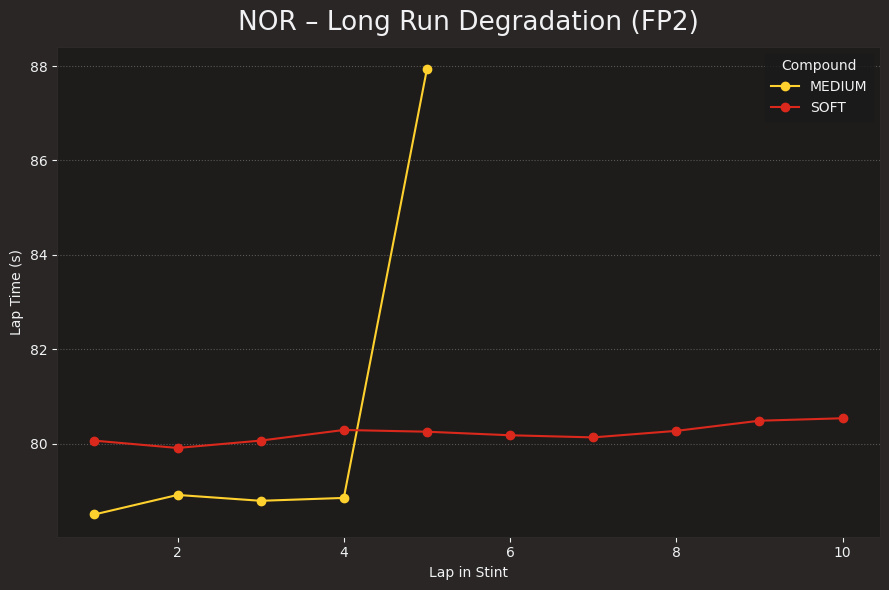

In [53]:
# Setup plotting
fastf1.plotting.setup_mpl(misc_mpl_mods=False, color_scheme='fastf1')

driver = 'NOR'  # change driver here

driver_runs = long_runs_deg[long_runs_deg['Driver'] == driver]

plt.figure(figsize=(9, 6))

for compound, df in driver_runs.groupby('Compound'):
    plt.plot(
        df['LapInStint'],
        df['LapTime_s'],
        marker='o',
        label=compound,
        color=fastf1.plotting.get_compound_color(compound, session)  # Use compound color
    )

plt.xlabel('Lap in Stint')
plt.ylabel('Lap Time (s)')
plt.title(f'{driver} – Long Run Degradation (FP2)')
plt.legend(title='Compound')
plt.grid(axis='y', linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()

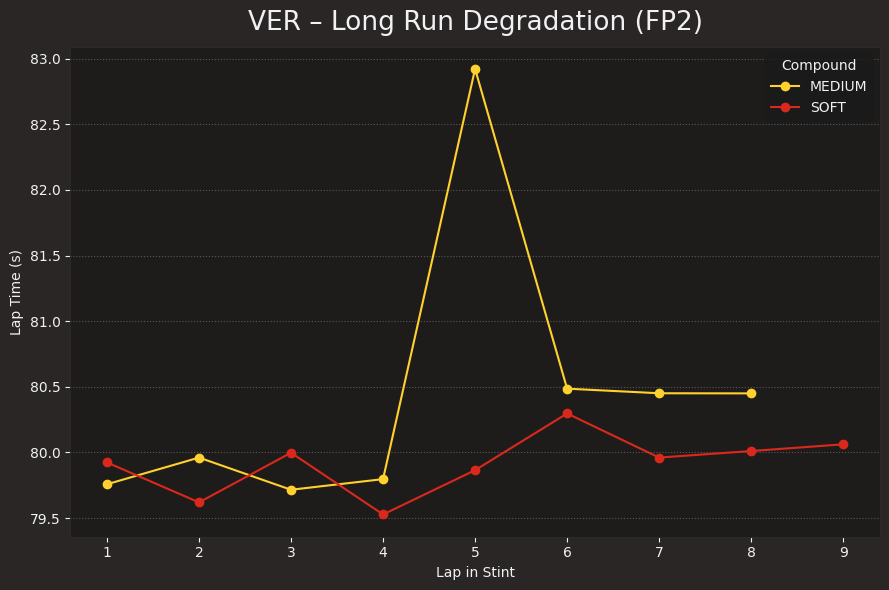

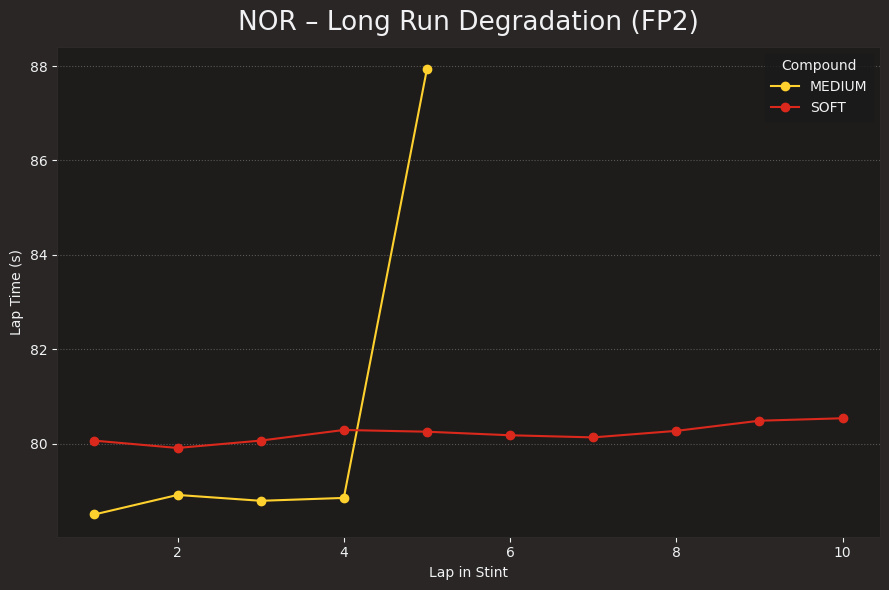

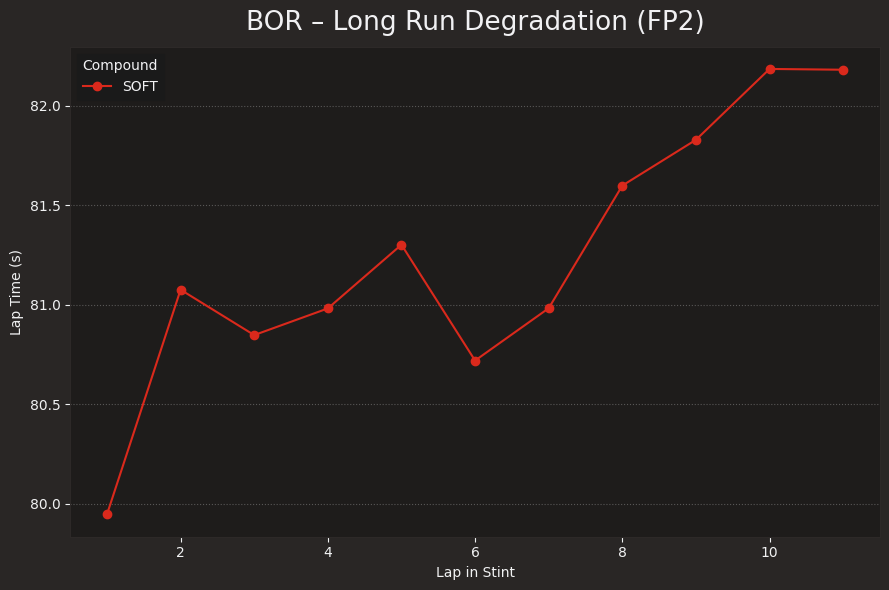

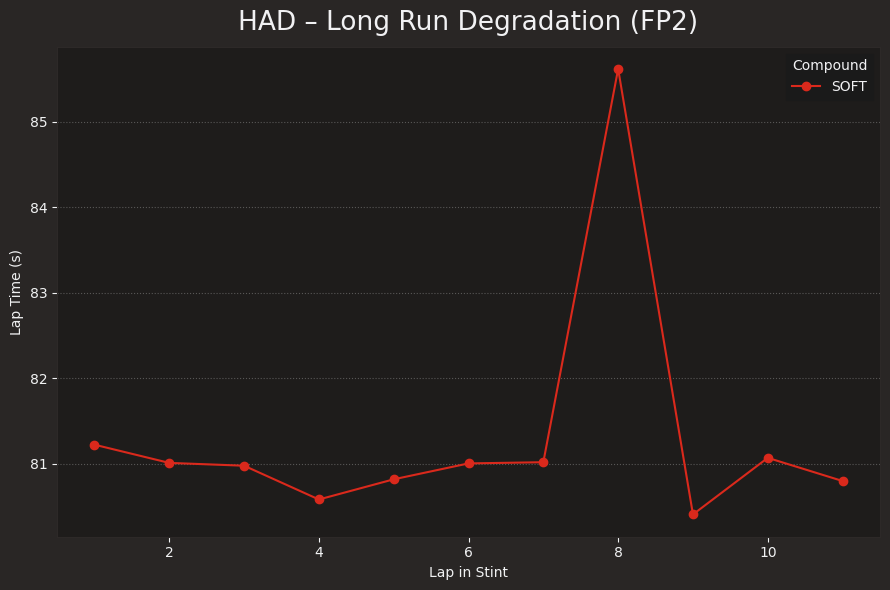

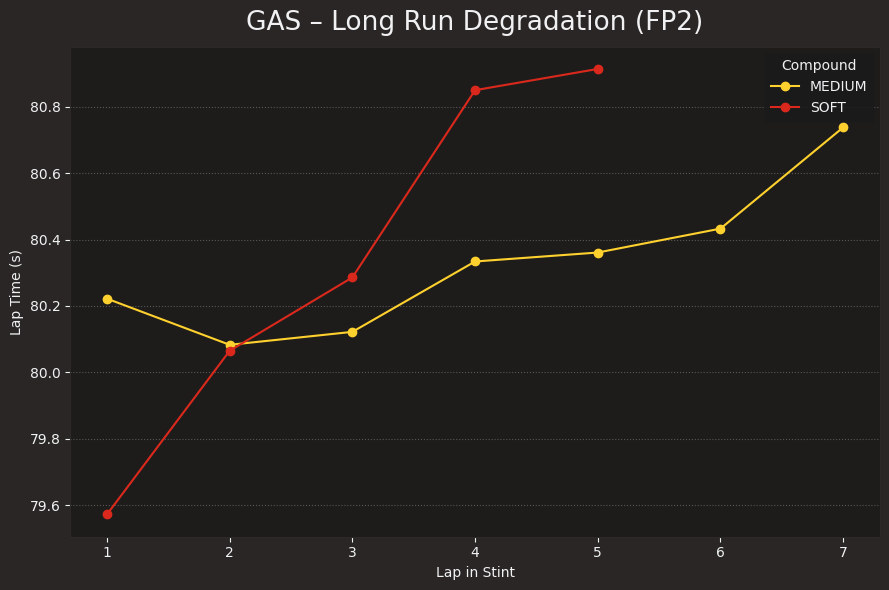

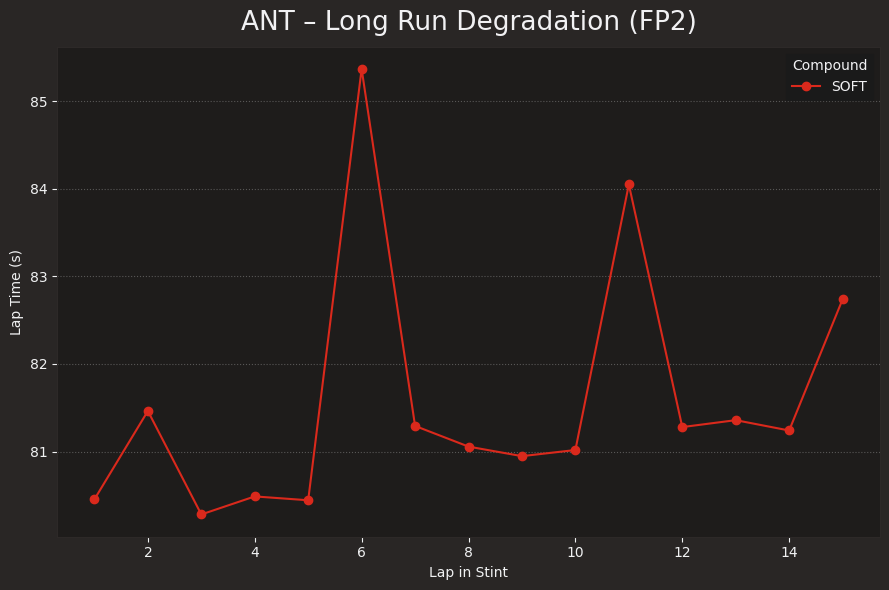

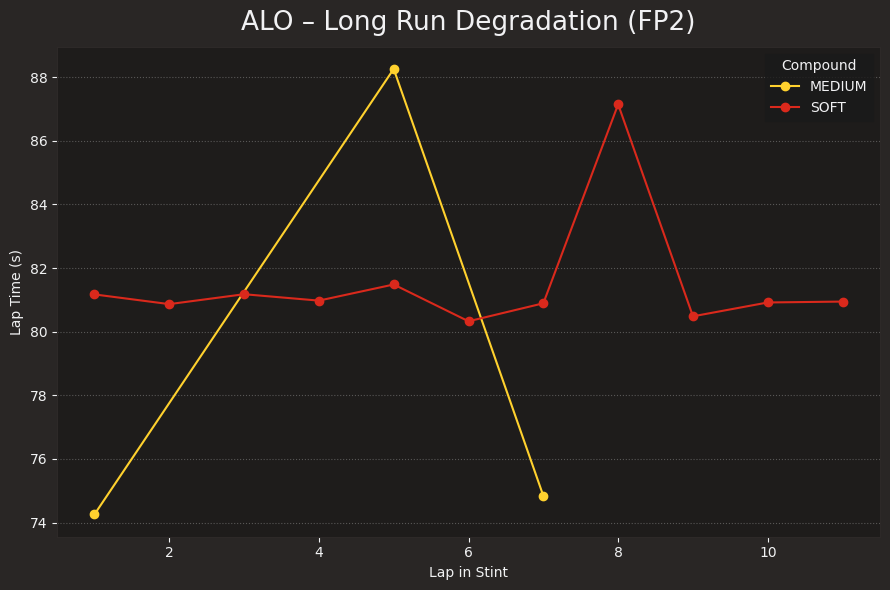

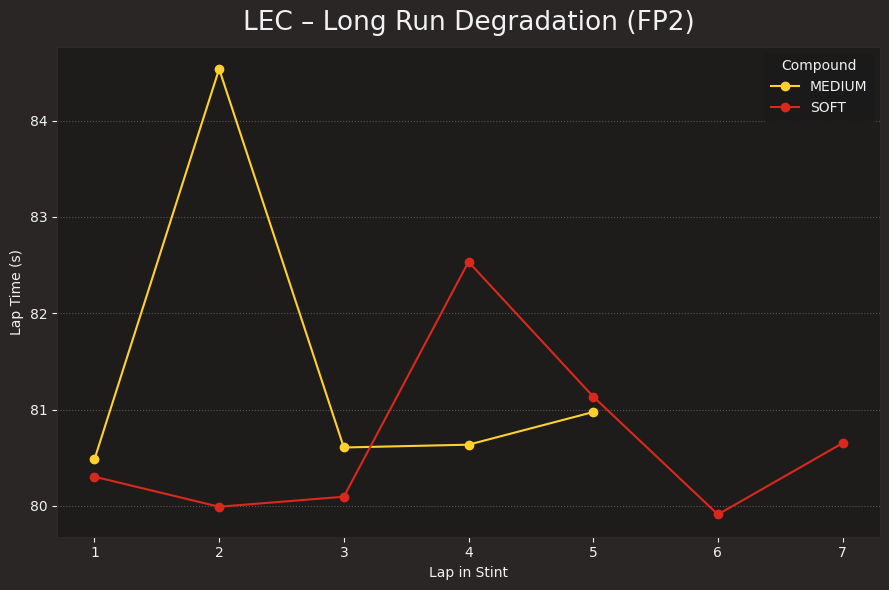

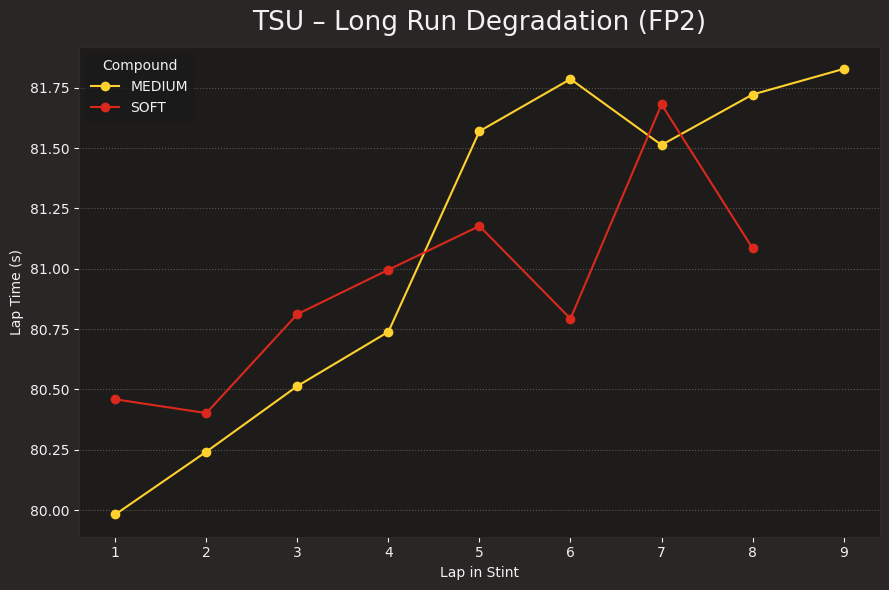

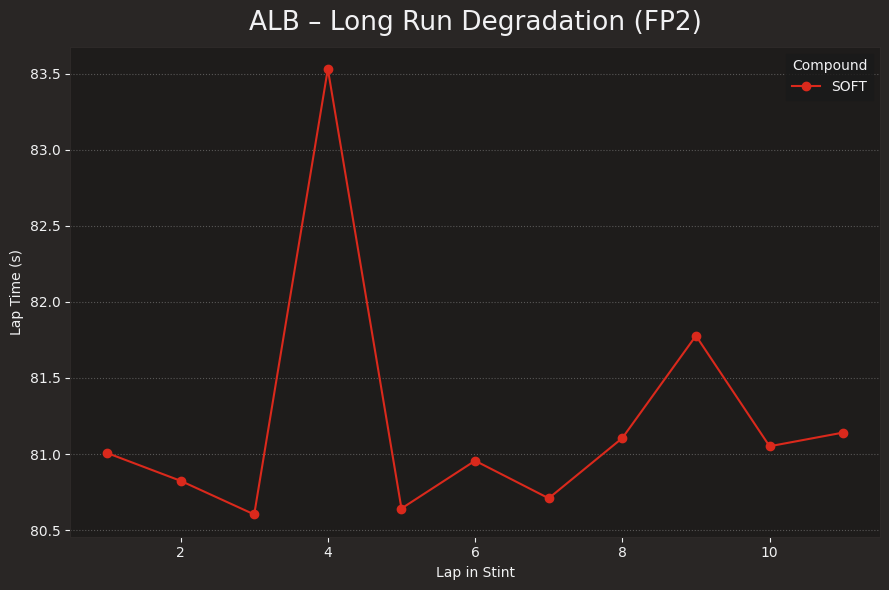

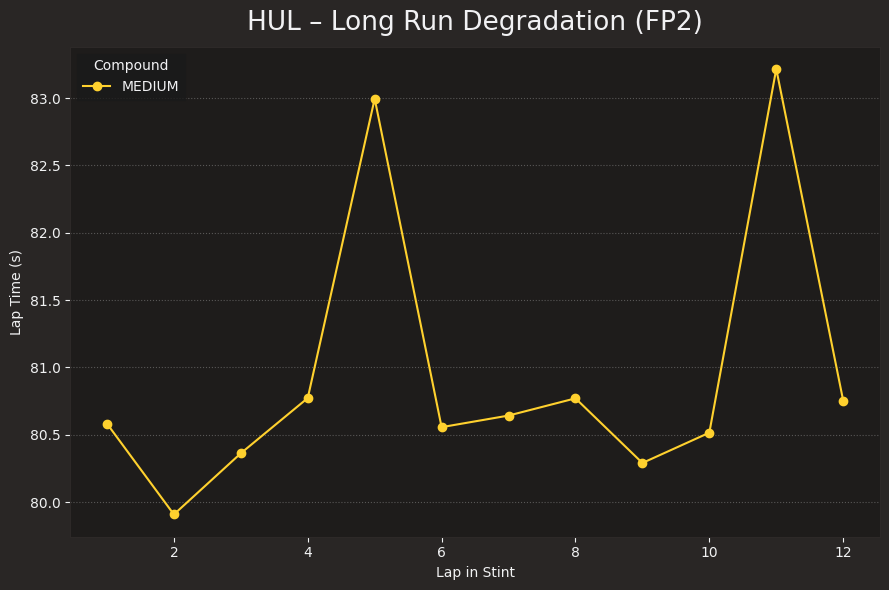

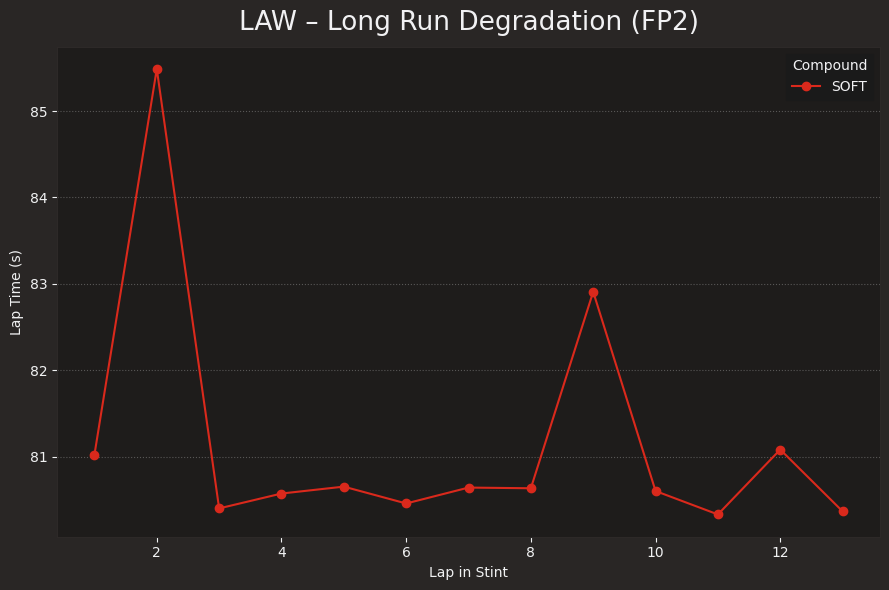

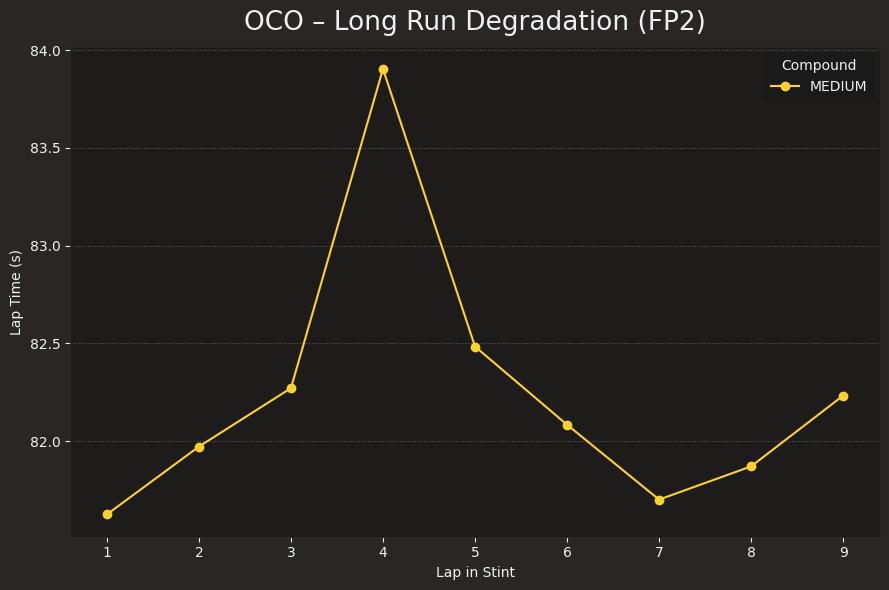

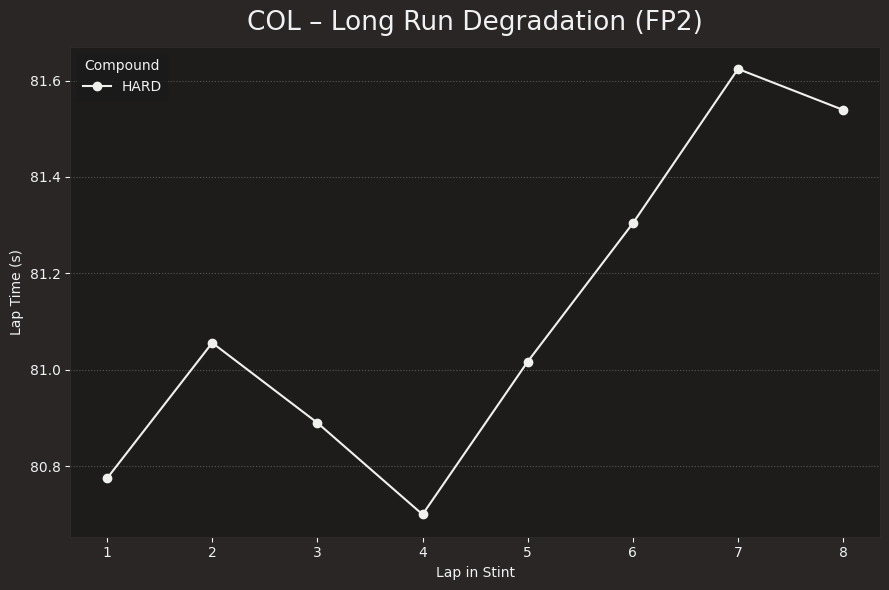

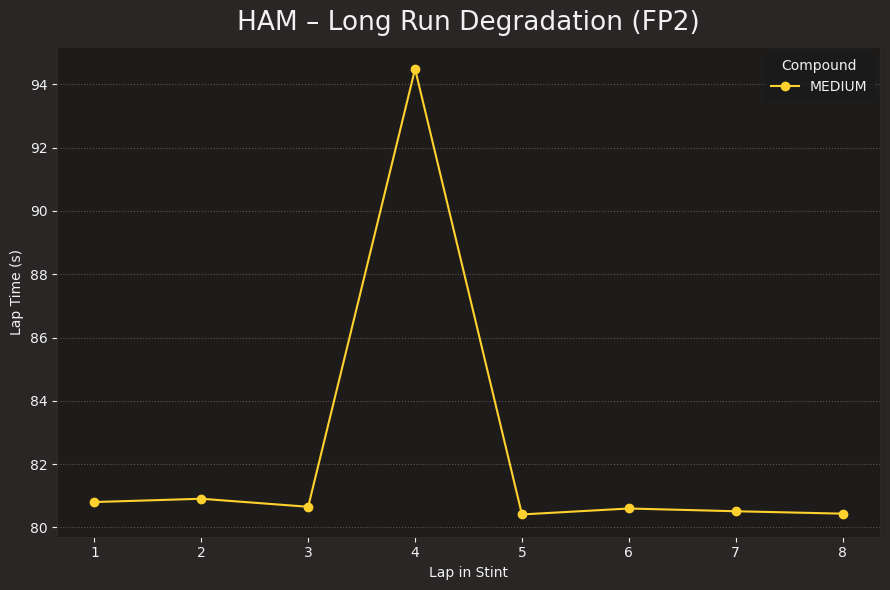

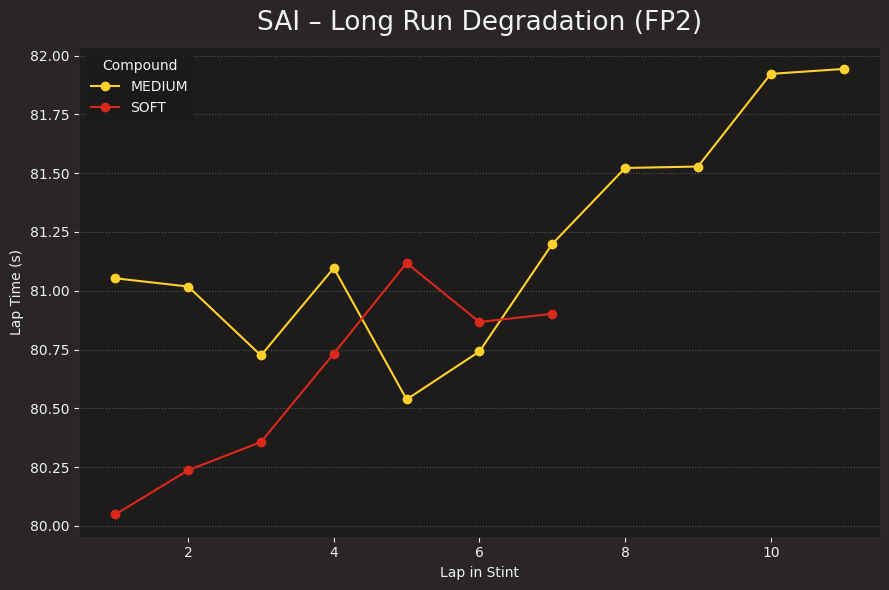

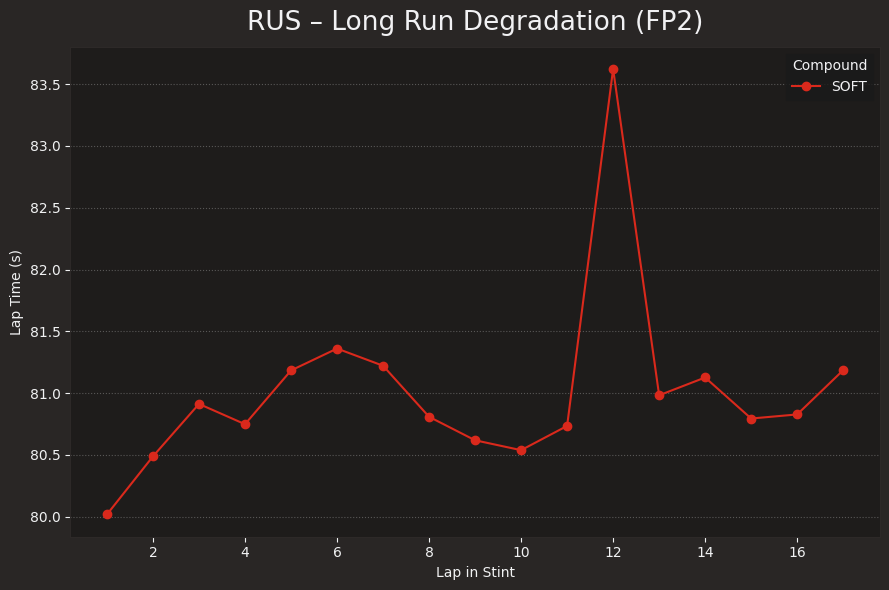

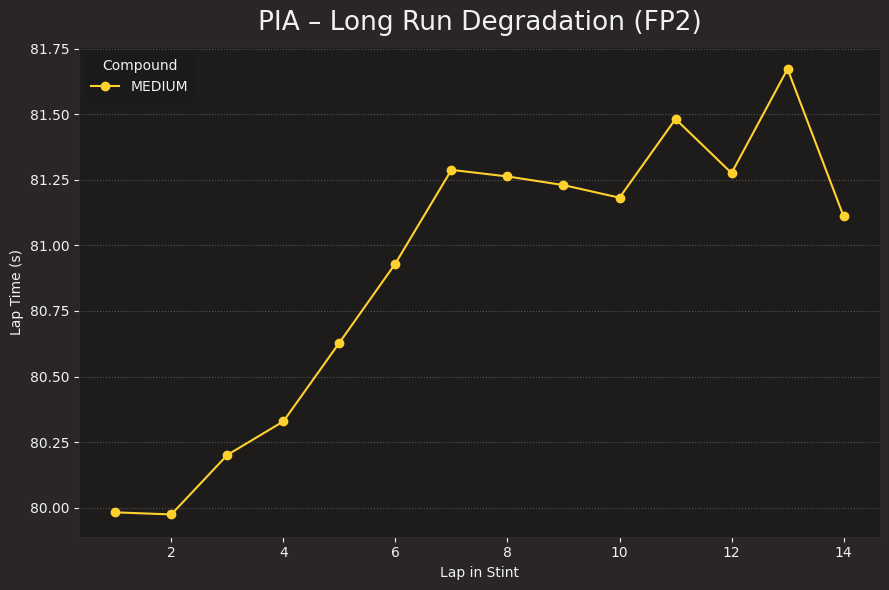

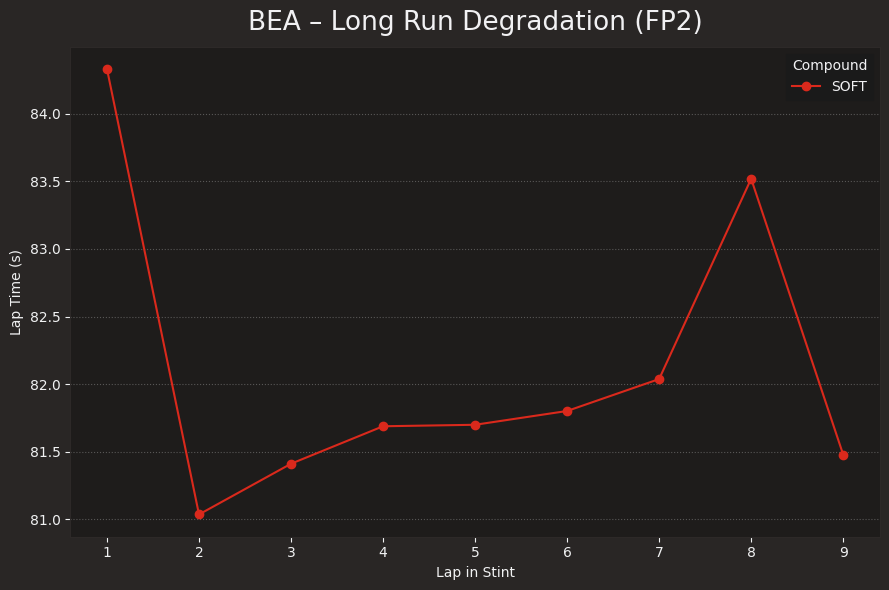

In [54]:
# Setup plotting
fastf1.plotting.setup_mpl(misc_mpl_mods=False, color_scheme='fastf1')

# Create a dictionary of driver colors for quick lookup
driver_color_dict = {drv: fastf1.plotting.get_driver_color(drv, session) for drv in long_runs_deg['Driver'].unique()}

for driver in long_runs_deg['Driver'].unique():
    driver_runs = long_runs_deg[long_runs_deg['Driver'] == driver]

    plt.figure(figsize=(9, 6))

    for compound, df in driver_runs.groupby('Compound'):
        plt.plot(
            df['LapInStint'],
            df['LapTime_s'],
            marker='o',
            label=compound,
            color=fastf1.plotting.get_compound_color(compound, session)  # Use compound color
        )

    plt.xlabel('Lap in Stint')
    plt.ylabel('Lap Time (s)')
    plt.title(f'{driver} – Long Run Degradation (FP2)')
    plt.legend(title='Compound')
    plt.grid(axis='y', linestyle=':', alpha=0.4)

    plt.tight_layout()
    plt.show()


Fuel Correction Lap

In [55]:
long_runs_fuel = long_runs_deg.copy()

long_runs_fuel['LapInStint'] = (
    long_runs_fuel
    .groupby(['Driver', 'Compound', 'Stint'])
    .cumcount() + 1
)


In [56]:
# Later laps are artificially faster due to less fuel

# We add time back to neutralize that advantage
FUEL_GAIN = 0.035  # seconds per lap (0.03 to 0.04 typical range based on tracks) HS-0.03 LS-0.04

long_runs_fuel['FuelCorrectedLap_s'] = (
    long_runs_fuel['LapTime_s'] +
    long_runs_fuel['LapInStint'] * FUEL_GAIN
)
long_runs_fuel

,Driver,DriverNumber,Team,LapTime,LapNumber,Stint,Compound,TyreLife,LapTime_s,LapInStint,IsPitInLap,FuelCorrectedLap_s
9,VER,1,Red Bull Racing,0 days 00:01:19.758000,10.0,4.0,MEDIUM,7.0,79.758,1,False,79.793
10,VER,1,Red Bull Racing,0 days 00:01:19.961000,11.0,4.0,MEDIUM,8.0,79.961,2,False,80.031
11,VER,1,Red Bull Racing,0 days 00:01:19.716000,12.0,4.0,MEDIUM,9.0,79.716,3,False,79.821
12,VER,1,Red Bull Racing,0 days 00:01:19.797000,13.0,4.0,MEDIUM,10.0,79.797,4,False,79.937
13,VER,1,Red Bull Racing,0 days 00:01:22.921000,14.0,4.0,MEDIUM,11.0,82.921,5,False,83.096
...,...,...,...,...,...,...,...,...,...,...,...,...
574,BEA,87,Haas F1 Team,0 days 00:01:21.700000,14.0,4.0,SOFT,9.0,81.700,5,False,81.875
575,BEA,87,Haas F1 Team,0 days 00:01:21.802000,15.0,4.0,SOFT,10.0,81.802,6,False,82.012
576,BEA,87,Haas F1 Team,0 days 00:01:22.038000,16.0,4.0,SOFT,11.0,82.038,7,False,82.283
577,BEA,87,Haas F1 Team,0 days 00:01:23.519000,17.0,4.0,SOFT,12.0,83.519,8,False,83.799


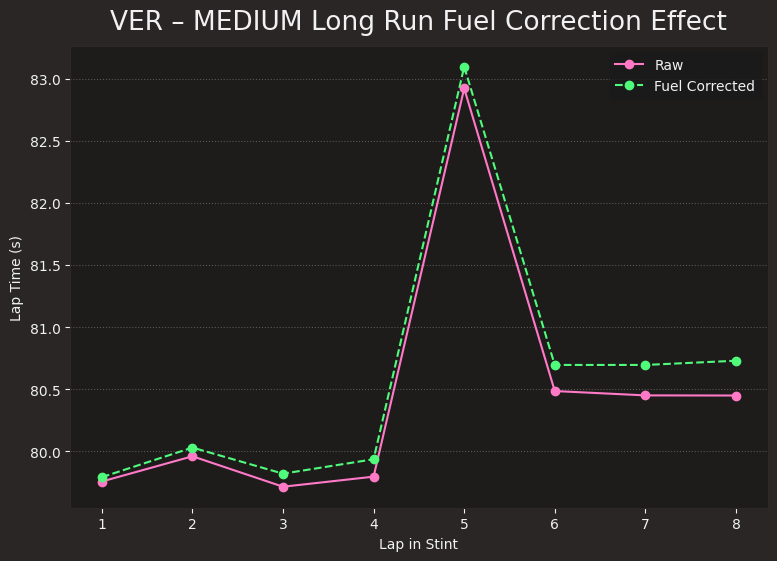

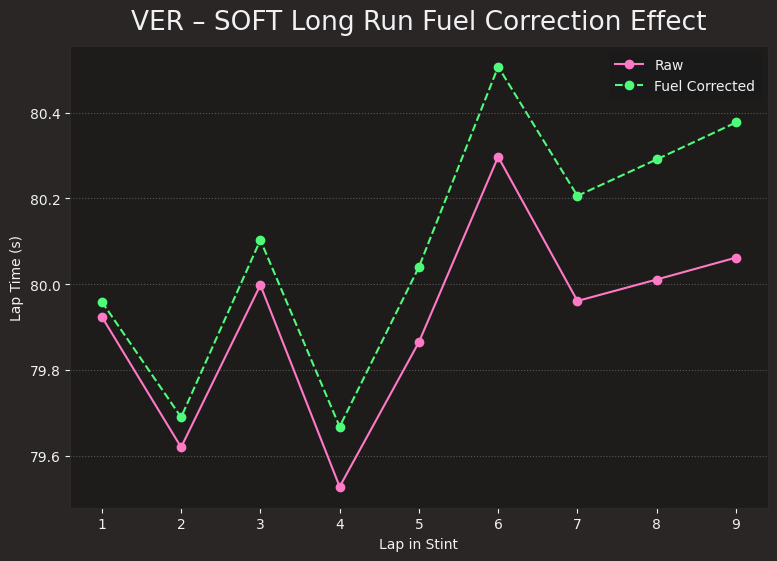

In [57]:
# Setup plotting
fastf1.plotting.setup_mpl(misc_mpl_mods=False, color_scheme='fastf1')

# Select a driver (change as needed)
driver = 'VER'  # e.g., 'VER', 'HAM', etc.

# Filter data for the selected driver
driver_fuel_data = long_runs_fuel[long_runs_fuel['Driver'] == driver]

# Group by compound and plot separately
for compound, df in driver_fuel_data.groupby('Compound'):
    plt.figure(figsize=(9,6))
    
    plt.plot(df['LapInStint'], df['LapTime_s'], 'o-', label='Raw')
    plt.plot(df['LapInStint'], df['FuelCorrectedLap_s'], 'o--', label='Fuel Corrected')
    
    plt.xlabel('Lap in Stint')
    plt.ylabel('Lap Time (s)')
    plt.title(f'{driver} – {compound} Long Run Fuel Correction Effect')
    plt.legend()
    plt.grid(axis='y', linestyle=':', alpha=0.4)
    
    plt.show()

A stint length simulator using fuel-corrected degradation

In [58]:
long_runs_sim = long_runs_fuel.copy()
long_runs_sim

,Driver,DriverNumber,Team,LapTime,LapNumber,Stint,Compound,TyreLife,LapTime_s,LapInStint,IsPitInLap,FuelCorrectedLap_s
9,VER,1,Red Bull Racing,0 days 00:01:19.758000,10.0,4.0,MEDIUM,7.0,79.758,1,False,79.793
10,VER,1,Red Bull Racing,0 days 00:01:19.961000,11.0,4.0,MEDIUM,8.0,79.961,2,False,80.031
11,VER,1,Red Bull Racing,0 days 00:01:19.716000,12.0,4.0,MEDIUM,9.0,79.716,3,False,79.821
12,VER,1,Red Bull Racing,0 days 00:01:19.797000,13.0,4.0,MEDIUM,10.0,79.797,4,False,79.937
13,VER,1,Red Bull Racing,0 days 00:01:22.921000,14.0,4.0,MEDIUM,11.0,82.921,5,False,83.096
...,...,...,...,...,...,...,...,...,...,...,...,...
574,BEA,87,Haas F1 Team,0 days 00:01:21.700000,14.0,4.0,SOFT,9.0,81.700,5,False,81.875
575,BEA,87,Haas F1 Team,0 days 00:01:21.802000,15.0,4.0,SOFT,10.0,81.802,6,False,82.012
576,BEA,87,Haas F1 Team,0 days 00:01:22.038000,16.0,4.0,SOFT,11.0,82.038,7,False,82.283
577,BEA,87,Haas F1 Team,0 days 00:01:23.519000,17.0,4.0,SOFT,12.0,83.519,8,False,83.799


In [59]:
# Assumptions (explicit)
# Fuel burn ≈ constant per lap
# Degradation slope is linear (first-order)
# No traffic, no safety car

# If degradation slope is steep:
# Undercut powerful

# If slope is flat:
# Track position more valuable

In [60]:
long_runs_sim_model = long_runs_sim[
    (long_runs_sim['LapInStint'] >= 2) &
    (~long_runs_sim['IsPitInLap'])
]


In [61]:
slope = np.polyfit(
    long_runs_sim_model['LapInStint'],
    long_runs_sim_model['FuelCorrectedLap_s'],
    1
)[0]

In [62]:
base_lap = long_runs_sim_model['FuelCorrectedLap_s'].median()


In [63]:
MAX_LAPS = 30
THRESHOLD = 0.5  # seconds from base pace

simulated = []

for lap in range(1, MAX_LAPS + 1):
    lap_time = base_lap + slope * lap
    delta = lap_time - base_lap

    simulated.append({
        'LapInStint': lap,
        'SimLapTime_s': lap_time,
        'DeltaFromBase_s': delta,
        'Viable': delta <= THRESHOLD
    })


In [64]:
sim_df = pd.DataFrame(simulated)
stint_length = sim_df[sim_df['Viable']].shape[0]


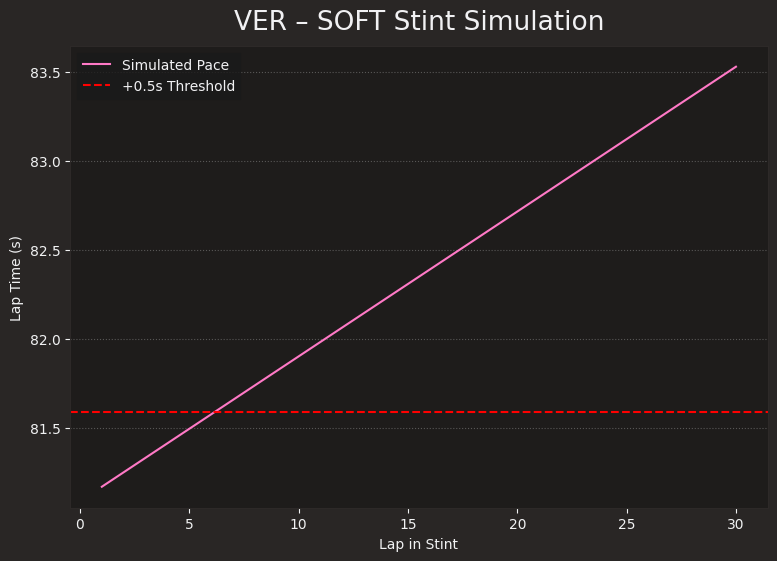

In [65]:
driver = 'VER'
compound = 'SOFT'

plt.figure(figsize=(9,6))

plt.plot(
    sim_df['LapInStint'],
    sim_df['SimLapTime_s'],
    label='Simulated Pace'
)

plt.axhline(
    base_lap + THRESHOLD,
    linestyle='--',
    color='red',
    label='+0.5s Threshold'
)

plt.xlabel('Lap in Stint')
plt.ylabel('Lap Time (s)')
plt.title(f'{driver} – {compound} Stint Simulation')
plt.legend()
plt.grid(axis='y', linestyle=':', alpha=0.4)

plt.show()


Plot rolling pace

In [66]:
long_runs_rolling_pace = long_runs_fuel.copy()
long_runs_rolling_pace

,Driver,DriverNumber,Team,LapTime,LapNumber,Stint,Compound,TyreLife,LapTime_s,LapInStint,IsPitInLap,FuelCorrectedLap_s
9,VER,1,Red Bull Racing,0 days 00:01:19.758000,10.0,4.0,MEDIUM,7.0,79.758,1,False,79.793
10,VER,1,Red Bull Racing,0 days 00:01:19.961000,11.0,4.0,MEDIUM,8.0,79.961,2,False,80.031
11,VER,1,Red Bull Racing,0 days 00:01:19.716000,12.0,4.0,MEDIUM,9.0,79.716,3,False,79.821
12,VER,1,Red Bull Racing,0 days 00:01:19.797000,13.0,4.0,MEDIUM,10.0,79.797,4,False,79.937
13,VER,1,Red Bull Racing,0 days 00:01:22.921000,14.0,4.0,MEDIUM,11.0,82.921,5,False,83.096
...,...,...,...,...,...,...,...,...,...,...,...,...
574,BEA,87,Haas F1 Team,0 days 00:01:21.700000,14.0,4.0,SOFT,9.0,81.700,5,False,81.875
575,BEA,87,Haas F1 Team,0 days 00:01:21.802000,15.0,4.0,SOFT,10.0,81.802,6,False,82.012
576,BEA,87,Haas F1 Team,0 days 00:01:22.038000,16.0,4.0,SOFT,11.0,82.038,7,False,82.283
577,BEA,87,Haas F1 Team,0 days 00:01:23.519000,17.0,4.0,SOFT,12.0,83.519,8,False,83.799


In [67]:
# Rolling pace is moving average of lap times
# To smooth fluctuations
# To ensure consistency, true race pace trend and tyre management trend

window = 3  # FP2 standard

long_runs_rolling_pace = long_runs_rolling_pace.sort_values('LapInStint')

long_runs_rolling_pace['RollingPace_s'] = (
    long_runs_rolling_pace
    .groupby(['Driver', 'Compound'])['FuelCorrectedLap_s']
    .rolling(window=window, min_periods=window)
    .mean()
    .reset_index(level=[0,1], drop=True)
)
long_runs_rolling_pace

,Driver,DriverNumber,Team,LapTime,LapNumber,Stint,Compound,TyreLife,LapTime_s,LapInStint,IsPitInLap,FuelCorrectedLap_s,RollingPace_s
9,VER,1,Red Bull Racing,0 days 00:01:19.758000,10.0,4.0,MEDIUM,7.0,79.758,1,False,79.793,NaN
19,VER,1,Red Bull Racing,0 days 00:01:19.924000,20.0,5.0,SOFT,5.0,79.924,1,False,79.959,NaN
54,NOR,4,McLaren,0 days 00:01:18.503000,25.0,6.0,MEDIUM,8.0,78.503,1,False,78.538,NaN
42,NOR,4,McLaren,0 days 00:01:20.066000,13.0,5.0,SOFT,7.0,80.066,1,False,80.101,NaN
131,GAS,10,Alpine,0 days 00:01:19.572000,15.0,6.0,SOFT,7.0,79.572,1,False,79.607,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
524,RUS,63,Mercedes,0 days 00:01:21.127000,24.0,4.0,SOFT,18.0,81.127,14,False,81.617,82.366000
171,ANT,12,Mercedes,0 days 00:01:22.738000,25.0,4.0,SOFT,19.0,82.738,15,False,83.263,82.268667
525,RUS,63,Mercedes,0 days 00:01:20.795000,25.0,4.0,SOFT,19.0,80.795,15,False,81.320,81.458333
526,RUS,63,Mercedes,0 days 00:01:20.828000,26.0,4.0,SOFT,20.0,80.828,16,False,81.388,81.441667


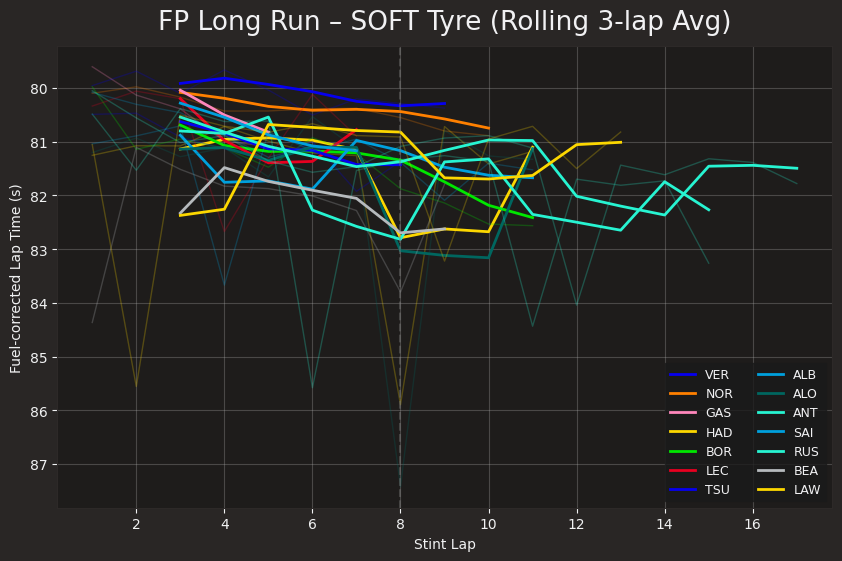

In [68]:
compound = 'SOFT'
drivers = long_runs_rolling_pace['Driver'].unique()
# Create a dictionary of driver colors for quick lookup
driver_color_dict = {drv: fastf1.plotting.get_driver_color(drv, session) for drv in long_runs_deg['Driver'].unique()}

plt.figure(figsize=(10,6))

for drv in drivers:
    data = long_runs_rolling_pace[
        (long_runs_rolling_pace['Driver'] == drv) &
        (long_runs_rolling_pace['Compound'] == compound)
    ]

    if len(data) < window + 1:
        continue

    # Raw pace (light)
    plt.plot(
        data['LapInStint'],
        data['FuelCorrectedLap_s'],
        alpha=0.25,
        linewidth=1,
        color=driver_color_dict[drv]
    )

    # Rolling pace (bold)
    plt.plot(
        data['LapInStint'],
        data['RollingPace_s'],
        linewidth=2,
        label=drv,
        color=driver_color_dict[drv]
    )

plt.gca().invert_yaxis()
plt.xlabel('Stint Lap')
plt.ylabel('Fuel-corrected Lap Time (s)')
plt.title(f'FP Long Run – {compound} Tyre (Rolling {window}-lap Avg)')
plt.legend(ncol=2, fontsize=9)
plt.grid(alpha=0.3)
plt.axvline(8, linestyle='--', color='gray', alpha=0.4)
# plt.text(x, y, 'annotation', fontsize=9)  # Add custom annotation if needed


plt.show()

# Smooth line: Consistency, stable tyre managment
# Fluctuating line: Inconsistent pace, possible tyre graining, traffic, or setup issues

Calculate degradation

In [69]:
long_runs_deg = long_runs_rolling_pace.copy()
long_runs_deg

,Driver,DriverNumber,Team,LapTime,LapNumber,Stint,Compound,TyreLife,LapTime_s,LapInStint,IsPitInLap,FuelCorrectedLap_s,RollingPace_s
9,VER,1,Red Bull Racing,0 days 00:01:19.758000,10.0,4.0,MEDIUM,7.0,79.758,1,False,79.793,NaN
19,VER,1,Red Bull Racing,0 days 00:01:19.924000,20.0,5.0,SOFT,5.0,79.924,1,False,79.959,NaN
54,NOR,4,McLaren,0 days 00:01:18.503000,25.0,6.0,MEDIUM,8.0,78.503,1,False,78.538,NaN
42,NOR,4,McLaren,0 days 00:01:20.066000,13.0,5.0,SOFT,7.0,80.066,1,False,80.101,NaN
131,GAS,10,Alpine,0 days 00:01:19.572000,15.0,6.0,SOFT,7.0,79.572,1,False,79.607,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
524,RUS,63,Mercedes,0 days 00:01:21.127000,24.0,4.0,SOFT,18.0,81.127,14,False,81.617,82.366000
171,ANT,12,Mercedes,0 days 00:01:22.738000,25.0,4.0,SOFT,19.0,82.738,15,False,83.263,82.268667
525,RUS,63,Mercedes,0 days 00:01:20.795000,25.0,4.0,SOFT,19.0,80.795,15,False,81.320,81.458333
526,RUS,63,Mercedes,0 days 00:01:20.828000,26.0,4.0,SOFT,20.0,80.828,16,False,81.388,81.441667


In [70]:
from scipy.stats import linregress
# Use linear regression for slopes 
def extract_degradation(stint_df):
    df = stint_df.dropna(subset=['RollingPace_s'])

    if len(df) < 5:
        return None

    res = linregress(df['LapInStint'], df['RollingPace_s'])

    return pd.Series({
        'Deg_s_per_lap': res.slope,
        'R2': res.rvalue ** 2,
        'StartLap': df['LapInStint'].min(),
        'EndLap': df['LapInStint'].max()
    })

# res.slope is the degradation time per lap
# r**2 is the score on how well the data is explained (0: poor fit, 1: perfect)

In [71]:
cols = ['LapInStint', 'RollingPace_s']

deg_results = (
    long_runs_deg
    .groupby(['Driver', 'Compound'])[cols]
    .apply(extract_degradation)
    .dropna()
    .reset_index()
)
deg_results



,Driver,Compound,Deg_s_per_lap,R2,StartLap,EndLap
0,ALB,SOFT,0.025789,0.037412,3.0,11.0
1,ALO,SOFT,0.193039,0.292986,3.0,11.0
2,ANT,SOFT,0.112326,0.307945,3.0,15.0
3,BEA,SOFT,0.129631,0.381957,3.0,9.0
4,BOR,SOFT,0.192072,0.888920,3.0,11.0
5,COL,HARD,0.159200,0.861140,3.0,8.0
6,GAS,MEDIUM,0.128300,0.981283,3.0,7.0
7,HAD,SOFT,0.170550,0.315332,3.0,11.0
8,HAM,MEDIUM,-0.419486,0.097146,3.0,8.0
9,HUL,MEDIUM,0.096972,0.282164,3.0,12.0


In [72]:
# To filter out unreliable results
clean_deg = deg_results[
    (deg_results['R2'] >= 0.6) &
    ((deg_results['EndLap'] - deg_results['StartLap']) >= 5) &
    (deg_results['Deg_s_per_lap'].between(-0.05, 0.4))
].copy()


In [73]:
compound_deg = (
    clean_deg
    .groupby('Compound')['Deg_s_per_lap']
    .mean()
    .reset_index()
)
compound_deg

,Compound,Deg_s_per_lap
0,HARD,0.159200
1,MEDIUM,0.205628
2,SOFT,0.131825


In [74]:
# Use weighted average for more reliable information 
clean_deg['StintLength'] = clean_deg['EndLap'] - clean_deg['StartLap'] + 1

compound_deg_weighted = (
    clean_deg
    .groupby('Compound')[['Deg_s_per_lap', 'StintLength']]
    .apply(
        lambda x: np.average(
            x['Deg_s_per_lap'],
            weights=x['StintLength']
        )
    )
    .reset_index(name='Deg_s_per_lap')
)

compound_deg_weighted

,Compound,Deg_s_per_lap
0,HARD,0.159200
1,MEDIUM,0.194569
2,SOFT,0.133028


In [75]:
compound_summary = (
    clean_deg
    .groupby('Compound')
    .agg(
        AvgDeg=('Deg_s_per_lap', 'mean'),
        StdDeg=('Deg_s_per_lap', 'std'),
        N=('Deg_s_per_lap', 'count')
    )
    .reset_index()
)
compound_summary

,Compound,AvgDeg,StdDeg,N
0,HARD,0.159200,NaN,1
1,MEDIUM,0.205628,0.079916,3
2,SOFT,0.131825,0.055512,4


In [76]:
compound_summary['StdDeg'] = (
    compound_summary['StdDeg'].fillna(0)
)
compound_summary

,Compound,AvgDeg,StdDeg,N
0,HARD,0.159200,0.000000,1
1,MEDIUM,0.205628,0.079916,3
2,SOFT,0.131825,0.055512,4


Convert degradation → stint length simulator

In [77]:
compound_summary.loc[compound_summary['Compound']=='SOFT',]

,Compound,AvgDeg,StdDeg,N
2,SOFT,0.131825,0.055512,4


In [78]:
long_runs_deg_stint = long_runs_deg.copy()
long_runs_deg_stint 


,Driver,DriverNumber,Team,LapTime,LapNumber,Stint,Compound,TyreLife,LapTime_s,LapInStint,IsPitInLap,FuelCorrectedLap_s,RollingPace_s
9,VER,1,Red Bull Racing,0 days 00:01:19.758000,10.0,4.0,MEDIUM,7.0,79.758,1,False,79.793,NaN
19,VER,1,Red Bull Racing,0 days 00:01:19.924000,20.0,5.0,SOFT,5.0,79.924,1,False,79.959,NaN
54,NOR,4,McLaren,0 days 00:01:18.503000,25.0,6.0,MEDIUM,8.0,78.503,1,False,78.538,NaN
42,NOR,4,McLaren,0 days 00:01:20.066000,13.0,5.0,SOFT,7.0,80.066,1,False,80.101,NaN
131,GAS,10,Alpine,0 days 00:01:19.572000,15.0,6.0,SOFT,7.0,79.572,1,False,79.607,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
524,RUS,63,Mercedes,0 days 00:01:21.127000,24.0,4.0,SOFT,18.0,81.127,14,False,81.617,82.366000
171,ANT,12,Mercedes,0 days 00:01:22.738000,25.0,4.0,SOFT,19.0,82.738,15,False,83.263,82.268667
525,RUS,63,Mercedes,0 days 00:01:20.795000,25.0,4.0,SOFT,19.0,80.795,15,False,81.320,81.458333
526,RUS,63,Mercedes,0 days 00:01:20.828000,26.0,4.0,SOFT,20.0,80.828,16,False,81.388,81.441667


In [79]:
# Soft:
base_soft = long_runs_deg_stint.loc[long_runs_deg_stint['Compound'] == 'SOFT', 'FuelCorrectedLap_s'].mean() #s
deg_soft  = compound_summary.loc[compound_summary['Compound'] == 'SOFT', 'AvgDeg'].iloc[0] #s/lap

# Medium:
base_medium = long_runs_deg_stint.loc[long_runs_deg_stint['Compound'] == 'MEDIUM', 'FuelCorrectedLap_s'].mean() #s
deg_medium  = compound_summary.loc[compound_summary['Compound'] == 'MEDIUM', 'AvgDeg'].iloc[0] #s/lap

In [90]:
print(f"Soft Compound Degradation: {deg_soft}s")
print(f"Medium Compound Degradation: {deg_medium}s")

Soft Compound Degradation: 0.13182519841269955s
Medium Compound Degradation: 0.20562809967810122s


In [80]:
def simulate_stint(
    base_pace,
    deg_slope,
    max_laps=40,
    cliff_lap=None,
    cliff_penalty=0.0
):
    laps = np.arange(1, max_laps + 1)

    lap_times = base_pace + deg_slope * laps

    if cliff_lap is not None:
        lap_times = np.where(
            laps >= cliff_lap,
            lap_times + cliff_penalty,
            lap_times
        )

    return pd.DataFrame({
        'LapInStint': laps,
        'LapTime_s': lap_times
    })


In [81]:
# Rule A — Delta threshold (most practical)
# End stint when lap time > base + X seconds

# Rule B — Crossover rule
# When Medium pace < Soft pace

# Rule C — Degradation acceleration
# When rolling slope increases sharply


In [82]:
def stint_length_from_delta(stint_df, delta_limit):
    base = stint_df['LapTime_s'].iloc[0]
    stint_df['Delta_s'] = stint_df['LapTime_s'] - base

    valid_laps = stint_df[stint_df['Delta_s'] <= delta_limit]

    return valid_laps['LapInStint'].max()


In [83]:
soft = simulate_stint(
    base_pace=base_soft,
    deg_slope=deg_soft,
    max_laps=25,
    cliff_lap=9,
    cliff_penalty=0.4
)

medium = simulate_stint(
    base_pace=base_medium,
    deg_slope=deg_medium,
    max_laps=30
)

soft_len = stint_length_from_delta(soft, delta_limit=1.2)
med_len  = stint_length_from_delta(medium, delta_limit=1.2)

soft_len, med_len


(np.int64(8), np.int64(6))

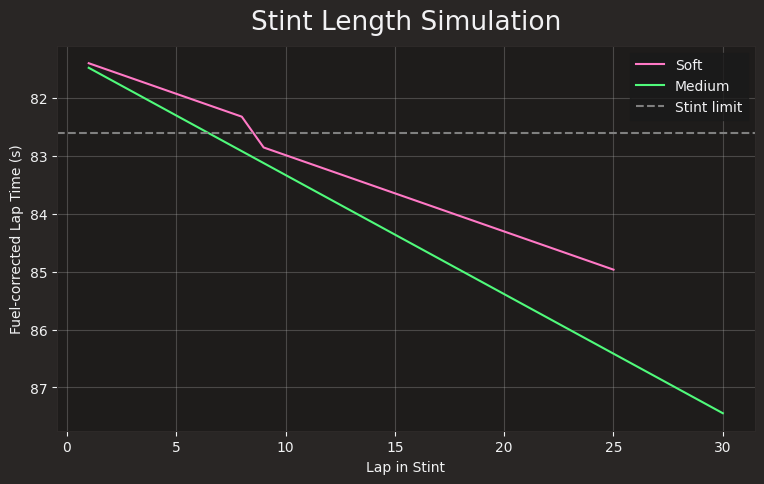

In [ ]:
plt.figure(figsize=(9,5))

plt.plot(soft['LapInStint'], soft['LapTime_s'], label='Soft')
plt.plot(medium['LapInStint'], medium['LapTime_s'], label='Medium')

plt.axhline(
    soft['LapTime_s'].iloc[0] + 1.2,
    linestyle='--',
    color='gray',
    label='Stint limit'
)

plt.gca().invert_yaxis()
plt.xlabel('Lap in Stint')
plt.ylabel('Fuel-corrected Lap Time (s)')
plt.title('Stint Length Simulation')
plt.legend()
plt.grid(alpha=0.3)

plt.show()
